# All final plots and analyses for figure 1

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import math
warnings.filterwarnings('ignore')
import joblib
import matplotlib.colors as mcolors

### Functions for plots from GrooD

### Figure 1A - CT metrics for pseudobulk framework (Hao dataset)

In [2]:
pd.read_csv('/ceph/ibmi/it/projects/ML_BI/16_GrooD/GrooD/grood_runs/GrooD_Hao_pseudobulk_new/intersect_CPM/pseudobulk/Pseudobulks.csv', index_col=0).shape

(1000, 19796)

In [3]:
pred = pd.read_csv('../../grood_runs/GrooD_Hao_pseudobulk_new/intersect_CPM/inference/MasterTable.csv', index_col=0)
pred.head()

,B cells,CD4 T cells,CD8 T cells,DC,Monocytes,NK cells,Tregs,Pred B cells,Pred CD4 T cells,Pred CD8 T cells,Pred DC,Pred Monocytes,Pred NK cells,Pred Tregs,SampleID,error
Sample_1,0.072435,0.354125,0.012072,0.317907,0.225352,0.000000,0.018109,0.078520,0.334190,0.008480,0.311386,0.208672,0.006637,0.019424,Sample_1,-0.001316
Sample_2,0.269076,0.198795,0.028112,0.036145,0.283133,0.158635,0.026104,0.273829,0.170196,0.028150,0.038992,0.283216,0.175564,0.030053,Sample_2,-0.003949
Sample_3,0.032193,0.464789,0.022133,0.000000,0.175050,0.295775,0.010060,0.032592,0.439337,0.019437,0.003109,0.178013,0.309697,0.017816,Sample_3,-0.007756
Sample_4,0.000000,0.042254,0.016097,0.472837,0.434608,0.020121,0.014085,0.006329,0.042651,0.019074,0.459967,0.428210,0.019802,0.019810,Sample_4,-0.005726
Sample_5,0.610442,0.253012,0.002008,0.042169,0.066265,0.000000,0.026104,0.597042,0.278658,0.003613,0.050729,0.046209,0.005899,0.017849,Sample_5,0.008256


In [4]:
# Correlation analysis

def getCorr(df, cellTypes):

    """
    Computes correlation and error metrics for predicitions vs. ground-truth as stored in the MasterTable
    df: MasterTable of samples x cell types (predicted proportions with prefix 'Pred ', groundtruth only with cell type name)
    cellTypes: basically list of cell types as in groundtruth
    """


    rsquared = []
    cccs = []
    rmses = []
    spearmans = []
    percent_dev = []
    absol_dev = []

    # Concordance correlation coefficient
    def ccc(x_data,y_data):
        sxy = np.sum((x_data - np.mean(x_data))*(y_data - np.mean(y_data)))/len(x_data)
        rhoc = 2*sxy / (np.var(x_data) + np.var(y_data) + (np.mean(x_data) - np.mean(y_data))**2)
        return rhoc


    # Pearson Correlation Coefficient
    def r(x_data,y_data):
        ''' Pearson Correlation Coefficient'''
        sxy = np.sum((x_data - np.mean(x_data))*(y_data - np.mean(y_data)))/len(x_data)
        rho = sxy / (np.std(x_data)*np.std(y_data))
        return rho


    # RMSE
    def rmse(x_data,y_data):
        MSE = np.mean(np.square((np.array(x_data)-np.array(y_data))))
        RMSE = np.sqrt(MSE)
        return RMSE

    # Spearmans rank correlation    
    def spearman(x_data, y_data):
        spearmanCorr, _ = stats.spearmanr(np.array(x_data), np.array(y_data))
        return spearmanCorr
    
    # Percent deviation function
    def frac_deviation(x_data, y_data):
        frac_devs = np.mean(np.divide((np.array(y_data) - np.array(x_data)),np.array(x_data), where=(np.array(x_data)!=0)))
        return frac_devs # for sparse data, quite some data points might be excluded due to the removal of 0-divisions from the mean
    
    # Absolute deviation function
    def abs_deviation(x_data, y_data):
        abs_devs = np.mean(abs(np.array(y_data) - np.array(x_data)))
        return abs_devs


    for cell in cellTypes:
        groundTruth = cell
        pred = 'Pred ' + cell
        
        xdata = df[groundTruth].tolist()
        ydata = df[pred].tolist()
        b = r(xdata, ydata)
        rsquared.append(b)
        c = ccc(xdata, ydata)
        cccs.append(c)
        a = rmse(xdata, ydata)
        rmses.append(a)
        g = abs_deviation(xdata, ydata)
        absol_dev.append(g)


        #print('R: ', str(b), ' for ', cell)
        #print('CCC: ', str(c), ' for ', cell)
        #print('SpearmanR: ', str(s), ' for ', cell)
        #print('RMSE: ', str(a), ' for ', cell)
        #print('Mean percent deviation: ', str(f), ' for ', cell)
        #print('Mean absolute deviation: ', str(g), ' for ', cell)

    DF = pd.concat([pd.Series(rsquared), pd.Series(cccs), pd.Series(rmses), pd.Series(absol_dev)], axis = 1, ignore_index = True)
    DF.columns = ['PCC', 'CCC', 'RMSE', 'MAD']
    DF.index = cellTypes

    return DF

corr_res = getCorr(pred, ['B cells', 'CD4 T cells',	'CD8 T cells', 'DC', 'Monocytes', 'NK cells', 'Tregs'])
corr_res

,PCC,CCC,RMSE,MAD
B cells,0.998085,0.997936,0.010356,0.007773
CD4 T cells,0.988018,0.984774,0.027492,0.022047
CD8 T cells,0.993644,0.992950,0.009899,0.006670
DC,0.998703,0.998607,0.008629,0.006577
Monocytes,0.996832,0.995896,0.012543,0.009541
NK cells,0.996704,0.996241,0.012970,0.009832
Tregs,0.989908,0.972701,0.022560,0.014142


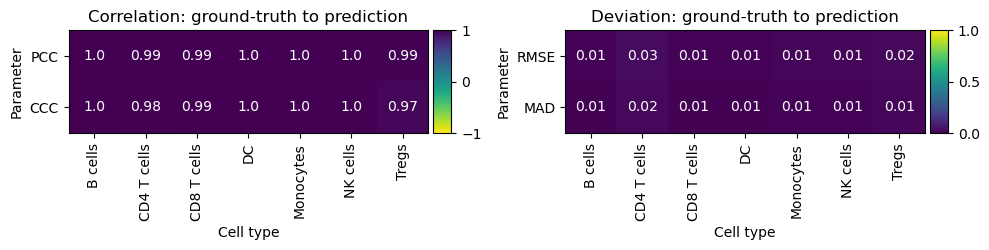

In [5]:
# Changed function for annotated heatmap

def annotated_heatmap(df, plot=False):

    """"
    Visualizes correlation and error metrics computed with getCorr in heatmaps with fixed scales
    df: output from getCorr
    """

    from mpl_toolkits.axes_grid1 import make_axes_locatable
    df1 = df.loc[['PCC', 'CCC']] # data for SCC, PCC, CCC
    df2 = df.loc[['RMSE', 'MAD']] # data for RMSE and percent deviation

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
    
    im1 = ax1.imshow(df1, vmin=-1, vmax=1, cmap='viridis_r')

    for i in range(df1.shape[0]):
        for j in range(df1.shape[1]): 
            ax1.annotate(str(round(df1.iloc[i,j], 2)), xy=(j, i), 
                        ha='center', va='center', color='white')

    ax1.set_title('Correlation: ground-truth to prediction')
    ax1.set_xlabel('Cell type')
    ax1.set_ylabel('Parameter')
    ax1.set_yticks(range(df1.shape[0]), df1.index.tolist())
    ax1.set_xticks(range(df1.shape[1]), df1.columns.tolist(), rotation = 'vertical')
    divider = make_axes_locatable(ax1)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im1, cax = cax, ax = ax1)

    # vir = plt.get_cmap("viridis")
    # cmap_bt = mcolors.LinearSegmentedColormap.from_list(
    #     "viridis_bt", vir(np.linspace(0.0, 0.5, 256))
    # )

    im2 = ax2.imshow(df2, vmin=0, vmax=1, cmap="viridis")

    for i in range(df2.shape[0]):
        for j in range(df2.shape[1]): 
            ax2.annotate(str(round(df2.iloc[i,j], 2)), xy=(j, i), 
                        ha='center', va='center', color='white')

    ax2.set_title('Deviation: ground-truth to prediction')
    ax2.set_xlabel('Cell type')
    ax2.set_ylabel('Parameter')
    ax2.set_yticks(range(df2.shape[0]), df2.index.tolist())
    ax2.set_xticks(range(df2.shape[1]), df2.columns.tolist(), rotation = 'vertical')
    divider = make_axes_locatable(ax2)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im2, cax = cax, ax = ax2)

    plt.tight_layout()
    if plot:
        plt.savefig('Figure_1A.svg', transparent = True, dpi = 300, format = 'svg')
    plt.show()

annotated_heatmap(corr_res.transpose(), True)

### SI Fig 1A

In [6]:
# Get convolution results using Hao and Finotello data account for cell type proportions
eval_res = pd.read_csv('../../../Convolution_control/nf_conv_02_2026/results_admiring_gates/Hao_Hao_500_cells_pb/viz_inter/viz_inter/Hao-2_notarget_500cells_random_pseudobulks_Hao_2_train_for_GRCh37_pseudobulks_only_metrics.csv', index_col=0)
#eval_res = eval_res.loc[eval_res['filter_strategy'] == 'none']
eval_res = eval_res.loc[eval_res['space'] == 'CPM']
eval_res = eval_res.loc[eval_res['metric'].isin(['Pearson', 'CCC', '1-JSD'])]
eval_res.replace({'none' : 'all', 'mRNA' : 'coding only'}, inplace=True)
eval_res = eval_res.loc[eval_res['dataset'] == 'ScadensSim']
eval_res.head()

,dataset,space,metric,value
800,ScadensSim,CPM,1-JSD,0.945858
801,ScadensSim,CPM,Pearson,0.998649
803,ScadensSim,CPM,CCC,0.988947
808,ScadensSim,CPM,1-JSD,0.875342
809,ScadensSim,CPM,Pearson,0.980044


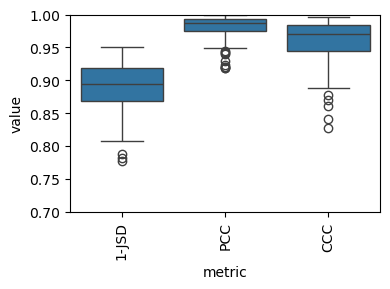

In [7]:
# Plot to visualize distribution of quality metrics

def boxplot_metrics(df, plot=False):

    """
    Creates boxplot of proportions per cell type across samples in pred
    pred: samples x cell types pandas dataframe
    output: target directory
    """
    plt.figure(figsize=(4,3))
    p = sns.boxplot(data=df, x = "metric", y = "value")
    p.set_xticklabels(p.get_xticklabels(), rotation=90)
    p.set_ylim([0.7,1])
    # plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, title = 'Gene subset')
    plt.xticks(np.arange(3), ['1-JSD', 'PCC', 'CCC'])
    plt.tight_layout()
    if plot:
        plt.savefig('SI_Figure_1A.svg', transparent = True, dpi = 300, format = 'svg')
    plt.show()

boxplot_metrics(eval_res, True)

### Figure 1B - Interpretability plots (feature importances)

In [8]:
model = joblib.load('../../grood_runs/GrooD_Hao_pseudobulk_new/intersect_CPM/train/model/Model.pkl')
model

{'metadata': {'estimators': ['B cells',
   'CD4 T cells',
   'CD8 T cells',
   'DC',
   'Monocytes',
   'NK cells',
   'Tregs'],
  'model_type': 'grood',
  'norm': 'CPM'},
 'model': MultiOutputRegressor(estimator=GradientBoostingRegressor(learning_rate=0.01,
                                                          max_depth=4,
                                                          min_samples_split=50,
                                                          n_estimators=500),
                      n_jobs=8)}

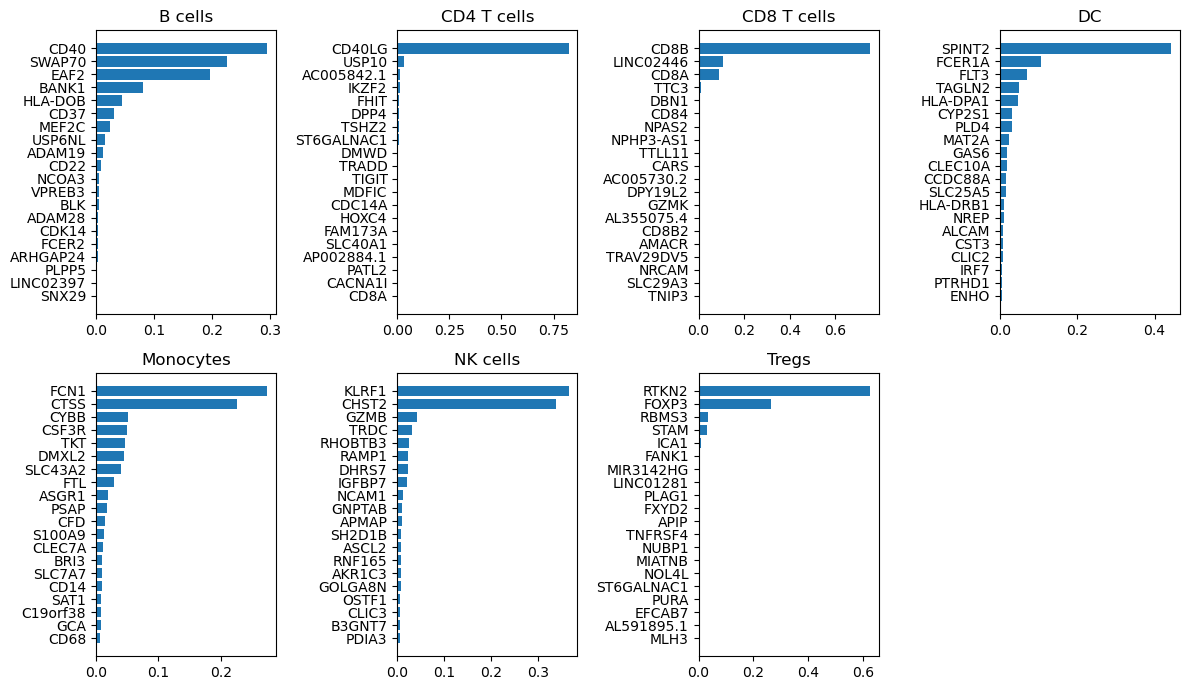

In [9]:
# Plotting feature importances
def plot_feature_importance(model, estimators):

    """
    For GrooD and XGrooD generates barplots of most important features per cell type model
    model: scikit-learn model for GrooD or XGrooD
    estimators: cell types in same order as described in model
    output: target directory for plot
    """
    
    # Get list of cellTypes (same order as in model estimators)
    cellTypes = estimators
    genes = model.estimators_[0].feature_names_in_.tolist()

    # Configure subplots
    n = len(cellTypes)
    rows = math.floor(math.sqrt(n))
    cols = math.ceil(n/rows)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3.5))
    axes = np.array(axes) # axes must be an iterable array

    axes = axes.flatten() # flatten in case of multi-dimensionality

    # iterate over n or cellTypes
    for i in range(0,len(cellTypes)):
        cellType = cellTypes[i]
        feature_importance = model.estimators_[i].feature_importances_
        sorted_idx = np.argsort(feature_importance) # sort highest to lowest importance and get the feature indices
        most_important_features = sorted_idx[-20:] # get 20 most important features
        pos = np.arange(most_important_features.shape[0]) + 0.5
        axes[i].barh(pos, feature_importance[most_important_features], align="center")
        axes[i].set_yticks(pos, np.array(genes)[most_important_features])
        axes[i].set_title(cellType)

    # Hide any unused axes
    for j in range(len(cellTypes), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.savefig('Figure_1B.svg', transparent = True, dpi = 300, format = 'svg')
    plt.show()

estimators = model['metadata']['estimators']
model_file = model['model']

plot_feature_importance(model_file, estimators)

### Figure 1C - Normalization frameworks for Hao pseudobulk framework

In [10]:
rank = pd.read_csv('../../grood_runs/GrooD_Hao_pseudobulk_new/intersect_rank/inference/Evaluated_inference_result.csv', index_col=0)
log = pd.read_csv('../../grood_runs/GrooD_Hao_pseudobulk_new/intersect_log/inference/Evaluated_inference_result.csv', index_col=0)
cpm = pd.read_csv('../../grood_runs/GrooD_Hao_pseudobulk_new/intersect_CPM/inference/Evaluated_inference_result.csv', index_col=0)

In [11]:
CCC_dict = {'CPM':cpm['CCC'].tolist(),
            'Log' : log['CCC'].tolist(),
            'Rank' : rank['CCC'].tolist()}
df = pd.DataFrame(CCC_dict, index=cpm.index.tolist())
df

,CPM,Log,Rank
B cells,0.997936,0.110254,0.996302
CD4 T cells,0.984774,0.030715,0.984230
CD8 T cells,0.992950,0.086242,0.990504
DC,0.998607,0.071385,0.997135
Monocytes,0.995896,0.061833,0.995887
NK cells,0.996241,0.116182,0.995302
Tregs,0.972701,0.084582,0.980575


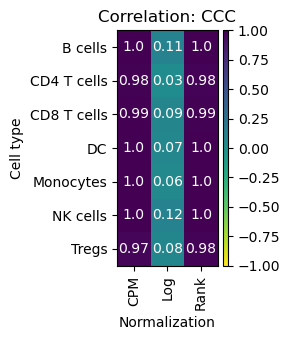

In [12]:
# Changed function for annotated heatmap

def annotated_heatmap(df):

    """"
    Visualizes correlation and error metrics computed with getCorr in heatmaps with fixed scales
    df: output from getCorr
    """

    from mpl_toolkits.axes_grid1 import make_axes_locatable

    fig, ax1 = plt.subplots(1, 1, figsize=(3, 3.5))
    
    im1 = ax1.imshow(df, vmin=-1, vmax=1, cmap='viridis_r')

    for i in range(df.shape[0]):
        for j in range(df.shape[1]): 
            ax1.annotate(str(round(df.iloc[i,j], 2)), xy=(j, i), 
                        ha='center', va='center', color='white')

    ax1.set_title(f'Correlation: CCC')
    ax1.set_xlabel('Normalization')
    ax1.set_ylabel('Cell type')
    ax1.set_yticks(range(df.shape[0]), df.index.tolist())
    ax1.set_xticks(range(df.shape[1]), df.columns.tolist(), rotation = 'vertical')
    divider = make_axes_locatable(ax1)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im1, cax = cax, ax = ax1)

    plt.tight_layout()
    plt.savefig('Figure_1C.svg', transparent = True, dpi = 300, format = 'svg')
    plt.show()

annotated_heatmap(df)

### Figure 1D - Convolution Hao - Finotello

In [13]:
# Get convolution results using Hao and Finotello data account for cell type proportions
eval_res = pd.read_csv('../../../Convolution_control/nf_conv_02_2026/results_admiring_gates/Hao_Finotello_props/viz_inter/viz_inter/Finotello_TPM_data_Hao_2_train_for_GRCh37_metrics.csv', index_col=0)
eval_res = eval_res.loc[eval_res['dataset'] == 'ConvolutionLike']
eval_res = eval_res.loc[eval_res['space'] == 'CPM']
eval_res = eval_res.loc[eval_res['metric'].isin(['Pearson', 'CCC', '1-JSD'])]
eval_res.replace({'Pearson' : 'PCC'}, inplace=True)
eval_res.head()

,dataset,space,metric,value
0,ConvolutionLike,CPM,1-JSD,0.715026
1,ConvolutionLike,CPM,PCC,0.571585
3,ConvolutionLike,CPM,CCC,0.537222
8,ConvolutionLike,CPM,1-JSD,0.708595
9,ConvolutionLike,CPM,PCC,0.589356


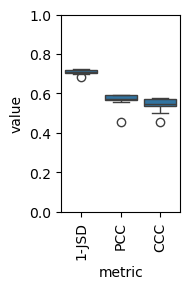

In [14]:
# Plot to visualize distribution of quality metrics

def boxplot_metrics(df):

    """
    Creates boxplot of proportions per cell type across samples in pred
    pred: samples x cell types pandas dataframe
    output: target directory
    """
    plt.figure(figsize=(2,3))
    p = sns.boxplot(data=df, x = "metric", y = "value", hue = "space", legend=False)
    p.set_xticklabels(p.get_xticklabels(), rotation=90)
    p.set_ylim([0,1])
    plt.tight_layout()
    plt.savefig('Figure_1D.svg', transparent = True, dpi = 300, format = 'svg')
    plt.show()

boxplot_metrics(eval_res)

### SI Figure 1B

In [15]:
# Get convolution results using Hao and Finotello data account for cell type proportions
eval_res = pd.read_csv('../../../Convolution_control/nf_conv_02_2026/results_admiring_gates/Hao_Finotello_props/viz_inter/viz_inter/Finotello_TPM_data_Hao_2_train_for_GRCh37_metrics.csv', index_col=0)
# eval_res = eval_res.loc[eval_res['filter_strategy'] == 'mRNA']
eval_res = eval_res.loc[eval_res['space'] == 'CPM']
eval_res = eval_res.loc[eval_res['dataset'] == 'ConvolutionLike']
eval_res = eval_res.loc[eval_res['metric'].isin(['Pearson', 'CCC', '1-JSD'])]
eval_res.replace({'Pearson' : 'PCC'}, inplace=True)
eval_res.replace({'none' : 'all', 'mRNA' : 'coding only'}, inplace=True)
eval_res.head()

,dataset,space,metric,value
0,ConvolutionLike,CPM,1-JSD,0.715026
1,ConvolutionLike,CPM,PCC,0.571585
3,ConvolutionLike,CPM,CCC,0.537222
8,ConvolutionLike,CPM,1-JSD,0.708595
9,ConvolutionLike,CPM,PCC,0.589356


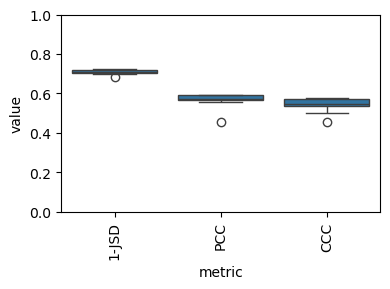

In [16]:
# Plot to visualize distribution of quality metrics

def boxplot_metrics(df):

    """
    Creates boxplot of proportions per cell type across samples in pred
    pred: samples x cell types pandas dataframe
    output: target directory
    """
    plt.figure(figsize=(4,3))
    p = sns.boxplot(data=df, x = "metric", y = "value")
    p.set_xticklabels(p.get_xticklabels(), rotation=90)
    p.set_ylim([0,1])
    # plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, title = 'Gene subset')
    plt.tight_layout()
    plt.savefig('SI_Figure_1B.svg', transparent = True, dpi = 300, format = 'svg')
    plt.show()

boxplot_metrics(eval_res)

### SI Figure 1C

In [17]:
# Get convolution results using Hao and Finotello data account for cell type proportions
eval_res = pd.read_csv('../../../Convolution_control/nf_conv_02_2026/results_admiring_gates/Hao_Finotello_no_props/viz_inter/viz_inter/Finotello_TPM_data_Hao_2_train_for_GRCh37_metrics.csv', index_col=0)
# eval_res = eval_res.loc[eval_res['filter_strategy'] == 'mRNA']
eval_res = eval_res.loc[eval_res['space'] == 'CPM']
eval_res = eval_res.loc[eval_res['dataset'] == 'ScadensSim']
eval_res = eval_res.loc[eval_res['metric'].isin(['Pearson', 'CCC', '1-JSD'])]
eval_res.replace({'Pearson' : 'PCC'}, inplace=True)
eval_res.replace({'none' : 'all', 'mRNA' : 'coding only'}, inplace=True)
eval_res.head()

,dataset,space,metric,value
72,ScadensSim,CPM,1-JSD,0.712512
73,ScadensSim,CPM,PCC,0.539955
75,ScadensSim,CPM,CCC,0.509218
80,ScadensSim,CPM,1-JSD,0.697462
81,ScadensSim,CPM,PCC,0.535726


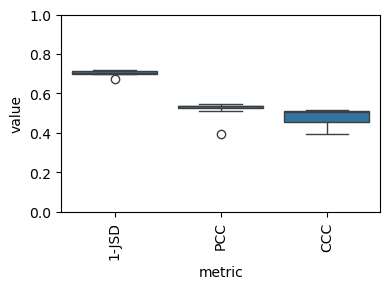

In [18]:
# Plot to visualize distribution of quality metrics

def boxplot_metrics(df):

    """
    Creates boxplot of proportions per cell type across samples in pred
    pred: samples x cell types pandas dataframe
    output: target directory
    """
    plt.figure(figsize=(4,3))
    p = sns.boxplot(data=df, x = "metric", y = "value")
    p.set_xticklabels(p.get_xticklabels(), rotation=90)
    p.set_ylim([0,1])
    # plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, title = 'Gene subset')
    plt.tight_layout()
    plt.savefig('SI_Figure_1C.svg', transparent = True, dpi = 300, format = 'svg')
    plt.show()

boxplot_metrics(eval_res)

### Figure 1E - Deconvolution Finotello

In [19]:
pred = pd.read_csv('../../grood_runs/revisions/hao_finotello/Finotello_counts_for_GRCh37_Hao_2_train_for_GRCh37_noMarkers_GCF_000001405.25_GRCh37.p13_genomic_Finotello_FACS_proportions_no_neutrophils_others_e1f2e9c7/predictions/grood.csv', index_col=0)
pred

,B cells,CD4 T cells,CD8 T cells,DC,Monocytes,NK cells,Tregs
sample,,,,,,,
pbmc_1,0.071425,0.320844,0.091059,0.156633,0.186576,0.103864,0.069599
pbmc_10,0.085747,0.271141,0.094849,0.177988,0.227325,0.076888,0.066062
pbmc_12,0.059285,0.241910,0.214045,0.131961,0.175559,0.132370,0.044870
pbmc_2,0.046763,0.319691,0.098996,0.178598,0.176207,0.111800,0.067945
pbmc_4,0.074976,0.273950,0.099681,0.072051,0.183644,0.216689,0.079008
pbmc_5,0.088099,0.213300,0.137362,0.087550,0.247499,0.148740,0.077449
pbmc_6,0.065059,0.164983,0.205689,0.164385,0.208436,0.117675,0.073773
pbmc_7,0.042327,0.191538,0.225699,0.138222,0.151939,0.202452,0.047822
pbmc_9,0.050455,0.263400,0.082887,0.084270,0.216186,0.203003,0.084022


In [20]:
gt = pd.read_csv('../../data/bulk_data/Finotello_2019/final_data/Finotello_FACS_proportions_no_neutrophils_others.csv', index_col=0)
gt

,NK cells,B cells,Tregs,DC,Monocytes,CD8 T cells,CD4 T cells
pbmc_1,0.0675,0.0581,0.0175,0.0160,0.2001,0.1564,0.3796
pbmc_10,0.0718,0.0640,0.0084,0.0227,0.3586,0.1839,0.1786
pbmc_12,0.1409,0.0516,0.0050,0.0426,0.2003,0.2984,0.1533
pbmc_2,0.1128,0.0296,0.0143,0.0234,0.2481,0.1638,0.2552
pbmc_4,0.1154,0.0384,0.0097,0.0357,0.1943,0.2452,0.2247
pbmc_5,0.0896,0.0606,0.0084,0.0424,0.2636,0.3661,0.0853
pbmc_6,0.1035,0.0645,0.0108,0.0242,0.3238,0.2834,0.0996
pbmc_7,0.1746,0.0403,0.0087,0.0329,0.2387,0.3227,0.1274
pbmc_9,0.1144,0.0480,0.0085,0.0476,0.2815,0.2260,0.1289


In [21]:
# Format and merge

pred = pred[gt.columns.tolist()]
pred.columns = [f"Pred {ct}" for ct in pred.columns.tolist()]
pred

,Pred NK cells,Pred B cells,Pred Tregs,Pred DC,Pred Monocytes,Pred CD8 T cells,Pred CD4 T cells
sample,,,,,,,
pbmc_1,0.103864,0.071425,0.069599,0.156633,0.186576,0.091059,0.320844
pbmc_10,0.076888,0.085747,0.066062,0.177988,0.227325,0.094849,0.271141
pbmc_12,0.132370,0.059285,0.044870,0.131961,0.175559,0.214045,0.241910
pbmc_2,0.111800,0.046763,0.067945,0.178598,0.176207,0.098996,0.319691
pbmc_4,0.216689,0.074976,0.079008,0.072051,0.183644,0.099681,0.273950
pbmc_5,0.148740,0.088099,0.077449,0.087550,0.247499,0.137362,0.213300
pbmc_6,0.117675,0.065059,0.073773,0.164385,0.208436,0.205689,0.164983
pbmc_7,0.202452,0.042327,0.047822,0.138222,0.151939,0.225699,0.191538
pbmc_9,0.203003,0.050455,0.084022,0.084270,0.216186,0.082887,0.263400


In [22]:
mt = pd.concat([gt, pred], axis=1)
mt

,NK cells,B cells,Tregs,DC,Monocytes,CD8 T cells,CD4 T cells,Pred NK cells,Pred B cells,Pred Tregs,Pred DC,Pred Monocytes,Pred CD8 T cells,Pred CD4 T cells
pbmc_1,0.0675,0.0581,0.0175,0.0160,0.2001,0.1564,0.3796,0.103864,0.071425,0.069599,0.156633,0.186576,0.091059,0.320844
pbmc_10,0.0718,0.0640,0.0084,0.0227,0.3586,0.1839,0.1786,0.076888,0.085747,0.066062,0.177988,0.227325,0.094849,0.271141
pbmc_12,0.1409,0.0516,0.0050,0.0426,0.2003,0.2984,0.1533,0.132370,0.059285,0.044870,0.131961,0.175559,0.214045,0.241910
pbmc_2,0.1128,0.0296,0.0143,0.0234,0.2481,0.1638,0.2552,0.111800,0.046763,0.067945,0.178598,0.176207,0.098996,0.319691
pbmc_4,0.1154,0.0384,0.0097,0.0357,0.1943,0.2452,0.2247,0.216689,0.074976,0.079008,0.072051,0.183644,0.099681,0.273950
pbmc_5,0.0896,0.0606,0.0084,0.0424,0.2636,0.3661,0.0853,0.148740,0.088099,0.077449,0.087550,0.247499,0.137362,0.213300
pbmc_6,0.1035,0.0645,0.0108,0.0242,0.3238,0.2834,0.0996,0.117675,0.065059,0.073773,0.164385,0.208436,0.205689,0.164983
pbmc_7,0.1746,0.0403,0.0087,0.0329,0.2387,0.3227,0.1274,0.202452,0.042327,0.047822,0.138222,0.151939,0.225699,0.191538
pbmc_9,0.1144,0.0480,0.0085,0.0476,0.2815,0.2260,0.1289,0.203003,0.050455,0.084022,0.084270,0.216186,0.082887,0.263400


In [23]:
corr_df = getCorr(mt, gt.columns.tolist())
corr_df

,PCC,CCC,RMSE,MAD
NK cells,0.621108,0.409430,0.051646,0.038005
B cells,0.659446,0.411071,0.018585,0.014337
Tregs,0.299269,0.007559,0.058952,0.057695
DC,-0.797361,-0.054886,0.111262,0.100462
Monocytes,0.605261,0.254420,0.073539,0.059514
CD8 T cells,0.697249,0.268204,0.121537,0.110626
CD4 T cells,0.834319,0.490194,0.087759,0.082852


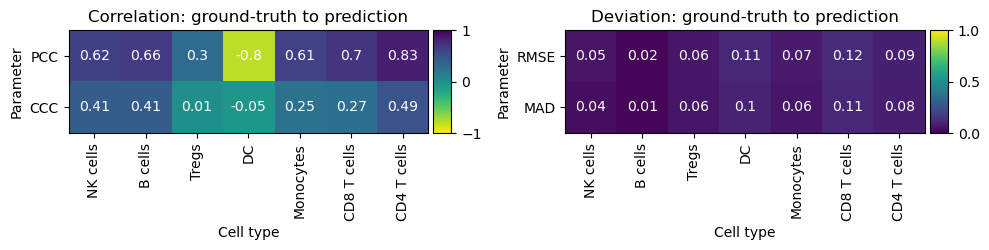

In [24]:
# Changed function for annotated heatmap

def annotated_heatmap(df):

    """"
    Visualizes correlation and error metrics computed with getCorr in heatmaps with fixed scales
    df: output from getCorr
    """

    from mpl_toolkits.axes_grid1 import make_axes_locatable
    df1 = df.loc[['PCC', 'CCC']] # data for SCC, PCC, CCC
    df2 = df.loc[['RMSE', 'MAD']] # data for RMSE and percent deviation

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
    
    im1 = ax1.imshow(df1, vmin=-1, vmax=1, cmap='viridis_r')

    for i in range(df1.shape[0]):
        for j in range(df1.shape[1]): 
            ax1.annotate(str(round(df1.iloc[i,j], 2)), xy=(j, i), 
                        ha='center', va='center', color='white')

    ax1.set_title('Correlation: ground-truth to prediction')
    ax1.set_xlabel('Cell type')
    ax1.set_ylabel('Parameter')
    ax1.set_yticks(range(df1.shape[0]), df1.index.tolist())
    ax1.set_xticks(range(df1.shape[1]), df1.columns.tolist(), rotation = 'vertical')
    divider = make_axes_locatable(ax1)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im1, cax = cax, ax = ax1)

    im2 = ax2.imshow(df2, vmin=0, vmax=1, cmap='viridis')

    for i in range(df2.shape[0]):
        for j in range(df2.shape[1]): 
            ax2.annotate(str(round(df2.iloc[i,j], 2)), xy=(j, i), 
                        ha='center', va='center', color='white')

    ax2.set_title('Deviation: ground-truth to prediction')
    ax2.set_xlabel('Cell type')
    ax2.set_ylabel('Parameter')
    ax2.set_yticks(range(df2.shape[0]), df2.index.tolist())
    ax2.set_xticks(range(df2.shape[1]), df2.columns.tolist(), rotation = 'vertical')
    divider = make_axes_locatable(ax2)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im2, cax = cax, ax = ax2)

    plt.tight_layout()
    plt.savefig('Figure_1E.svg', transparent = True, dpi = 300, format = 'svg')
    plt.show()

annotated_heatmap(corr_df.transpose())

### SI Figure 1D

In [25]:
# Generate QC metrics per cell type and tool

from scipy import stats

def getCorr(df, groundTruth):

    """
    Computes correlation and error metrics for predicitions vs. ground-truth as stored in the MasterTable
    df: predictions
    groundTruth
    """


    rsquared = []
    cccs = []
    rmses = []
    spearmans = []
    percent_dev = []
    absol_dev = []

    # Concordance correlation coefficient
    def ccc(x_data,y_data):
        sxy = np.sum((x_data - np.mean(x_data))*(y_data - np.mean(y_data)))/len(x_data)
        rhoc = 2*sxy / (np.var(x_data) + np.var(y_data) + (np.mean(x_data) - np.mean(y_data))**2)
        return rhoc


    # Pearson Correlation Coefficient
    def r(x_data,y_data):
        ''' Pearson Correlation Coefficient'''
        sxy = np.sum((x_data - np.mean(x_data))*(y_data - np.mean(y_data)))/len(x_data)
        rho = sxy / (np.std(x_data)*np.std(y_data))
        return rho


    # RMSE
    def rmse(x_data,y_data):
        MSE = np.mean(np.square((np.array(x_data)-np.array(y_data))))
        RMSE = np.sqrt(MSE)
        return RMSE

    # Spearmans rank correlation    
    def spearman(x_data, y_data):
        spearmanCorr, _ = stats.spearmanr(np.array(x_data), np.array(y_data))
        return spearmanCorr
    
    # Percent deviation function
    def frac_deviation(x_data, y_data):
        frac_devs = np.mean(np.divide((np.array(y_data) - np.array(x_data)),np.array(x_data), where=(np.array(x_data)!=0)))
        return frac_devs # for sparse data, quite some data points might be excluded due to the removal of 0-divisions from the mean
    
    # Absolute deviation function
    def abs_deviation(x_data, y_data):
        abs_devs = np.mean(abs(np.array(y_data) - np.array(x_data)))
        return abs_devs

    samples = groundTruth.index.tolist()

    for sample in samples:
        
        xdata = df.loc[sample].tolist()
        ydata = groundTruth.loc[sample].tolist()
        b = r(xdata, ydata)
        rsquared.append(b)
        s = spearman(xdata, ydata)
        spearmans.append(s)
        c = ccc(xdata, ydata)
        cccs.append(c)
        a = rmse(xdata, ydata)
        rmses.append(a)
        f = frac_deviation(xdata, ydata)
        percent_dev.append(f)
        g = abs_deviation(xdata, ydata)
        absol_dev.append(g)

    DF = pd.concat([pd.Series(rsquared), pd.Series(spearmans), pd.Series(cccs), pd.Series(rmses), pd.Series(percent_dev), pd.Series(absol_dev)], axis = 1, ignore_index = True)
    DF.columns = ['PCC', 'SCC', 'CCC', 'RMSE', 'RD', 'MAD']
    DF.index = samples

    return DF


    
df = pred
df.sort_index(axis=1, inplace=True)
gt = gt
gt.sort_index(axis=1, inplace=True)

metrics = getCorr(df, gt)
metrics.head()


,PCC,SCC,CCC,RMSE,RD,MAD
pbmc_1,0.856144,0.607143,0.791022,0.067503,-0.172843,0.054292
pbmc_10,0.592541,0.607143,0.539579,0.093858,-0.127151,0.078950
pbmc_12,0.795467,0.857143,0.741323,0.060103,-0.208886,0.049022
pbmc_2,0.684032,0.535714,0.660273,0.076333,-0.165102,0.061170
pbmc_4,0.614622,0.642857,0.587933,0.076939,-0.142704,0.064136


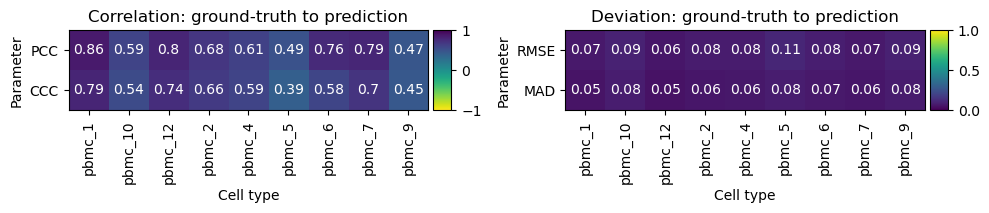

In [26]:
# Changed function for annotated heatmap

def annotated_heatmap(df):

    """"
    Visualizes correlation and error metrics computed with getCorr in heatmaps with fixed scales
    df: output from getCorr
    """

    from mpl_toolkits.axes_grid1 import make_axes_locatable
    df1 = df.loc[['PCC', 'CCC']] # data for SCC, PCC, CCC
    df2 = df.loc[['RMSE', 'MAD']] # data for RMSE and percent deviation

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
    
    im1 = ax1.imshow(df1, vmin=-1, vmax=1, cmap='viridis_r')

    for i in range(df1.shape[0]):
        for j in range(df1.shape[1]): 
            ax1.annotate(str(round(df1.iloc[i,j], 2)), xy=(j, i), 
                        ha='center', va='center', color='white')

    ax1.set_title('Correlation: ground-truth to prediction')
    ax1.set_xlabel('Cell type')
    ax1.set_ylabel('Parameter')
    ax1.set_yticks(range(df1.shape[0]), df1.index.tolist())
    ax1.set_xticks(range(df1.shape[1]), df1.columns.tolist(), rotation = 'vertical')
    divider = make_axes_locatable(ax1)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im1, cax = cax, ax = ax1)

    im2 = ax2.imshow(df2, vmin=0, vmax=1, cmap='viridis')

    for i in range(df2.shape[0]):
        for j in range(df2.shape[1]): 
            ax2.annotate(str(round(df2.iloc[i,j], 2)), xy=(j, i), 
                        ha='center', va='center', color='white')

    ax2.set_title('Deviation: ground-truth to prediction')
    ax2.set_xlabel('Cell type')
    ax2.set_ylabel('Parameter')
    ax2.set_yticks(range(df2.shape[0]), df2.index.tolist())
    ax2.set_xticks(range(df2.shape[1]), df2.columns.tolist(), rotation = 'vertical')
    divider = make_axes_locatable(ax2)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im2, cax = cax, ax = ax2)

    plt.tight_layout()
    plt.savefig('SI_Figure_1D.svg', transparent = True, dpi = 300, format = 'svg')
    plt.show()

annotated_heatmap(metrics.transpose())

### Investigate marker gene expression on DCs

In [48]:
def plot_marker_prop_expression_correlation(model, cellType, pb, props, estimators, plot=None):
    
    # Get list of cellTypes (same order as in model estimators)
    genes = model.estimators_[0].feature_names_in_.tolist()

    # Configure subplots
    n = 10
    rows = math.floor(math.sqrt(n))
    cols = math.ceil(n/rows)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3.5))
    axes = np.array(axes) # axes must be an iterable array

    axes = axes.flatten() # flatten in case of multi-dimensionality

    cellType_pos = estimators.index(cellType)
    feature_importance = model.estimators_[cellType_pos].feature_importances_
    sorted_idx = np.argsort(feature_importance) # sort highest to lowest importance and get the feature indices
    most_important_features = sorted_idx[-n:] # get n most important features
    marker_genes = np.array(genes)[most_important_features]
    marker_genes = list(marker_genes)

    for gene in marker_genes:
        if gene not in pb.columns.tolist():
            marker_genes.remove(gene)

    df_plot = pd.concat([props[cellType], pb[marker_genes]], axis=1)

    # iterate over n or cellTypes
    for i, gene in enumerate(marker_genes):
        plot_df = df_plot[[gene, cellType]]
        sns.regplot(plot_df, x=gene, y=cellType, ax=axes[i])
        axes[i].set_title(gene)

    # # Hide any unused axes
    # for j in range(len(cellTypes), len(axes)):
    #     fig.delaxes(axes[j])

    plt.suptitle(cellType)
    plt.tight_layout()
    if plot is not None:
        plt.savefig(f'SI_Figure_1E_{plot}.svg', transparent = True, dpi = 300, format = 'svg')
    plt.show()

estimators = model['metadata']['estimators']

In [40]:
# Pseudobulk example data
pbs = pd.read_csv('../../grood_runs/GrooD_Hao_pseudobulk_new/intersect_CPM/pseudobulk/Pseudobulks.csv', index_col=0)
pb_props = pd.read_csv('../../grood_runs/GrooD_Hao_pseudobulk_new/intersect_CPM/pseudobulk/Pseudobulk_proprotions.csv', index_col=0)

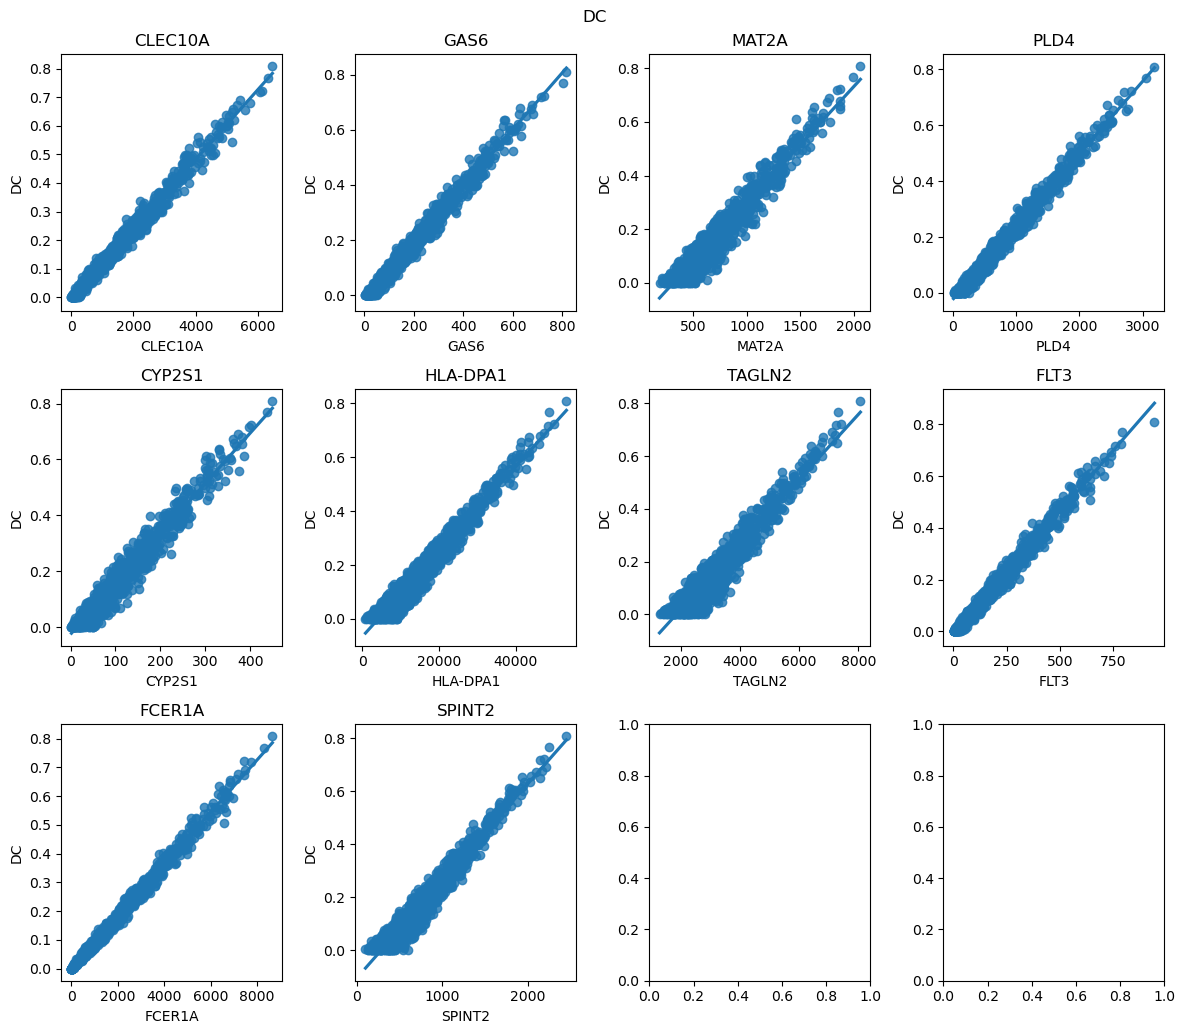

In [41]:
plot_marker_prop_expression_correlation(model['model'], 'DC', pbs, pb_props, estimators, "DC_pb_full_spectrum")

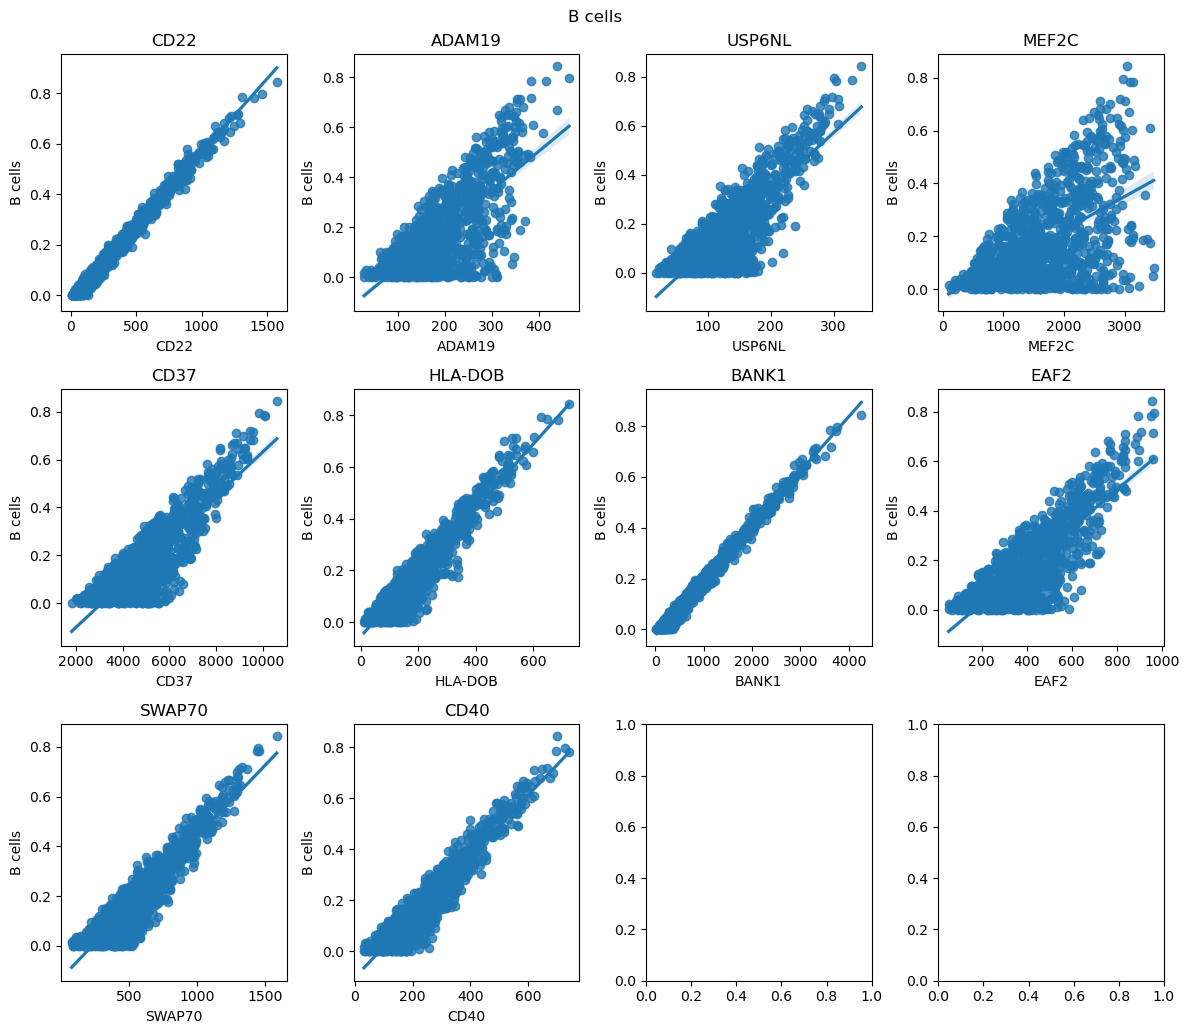

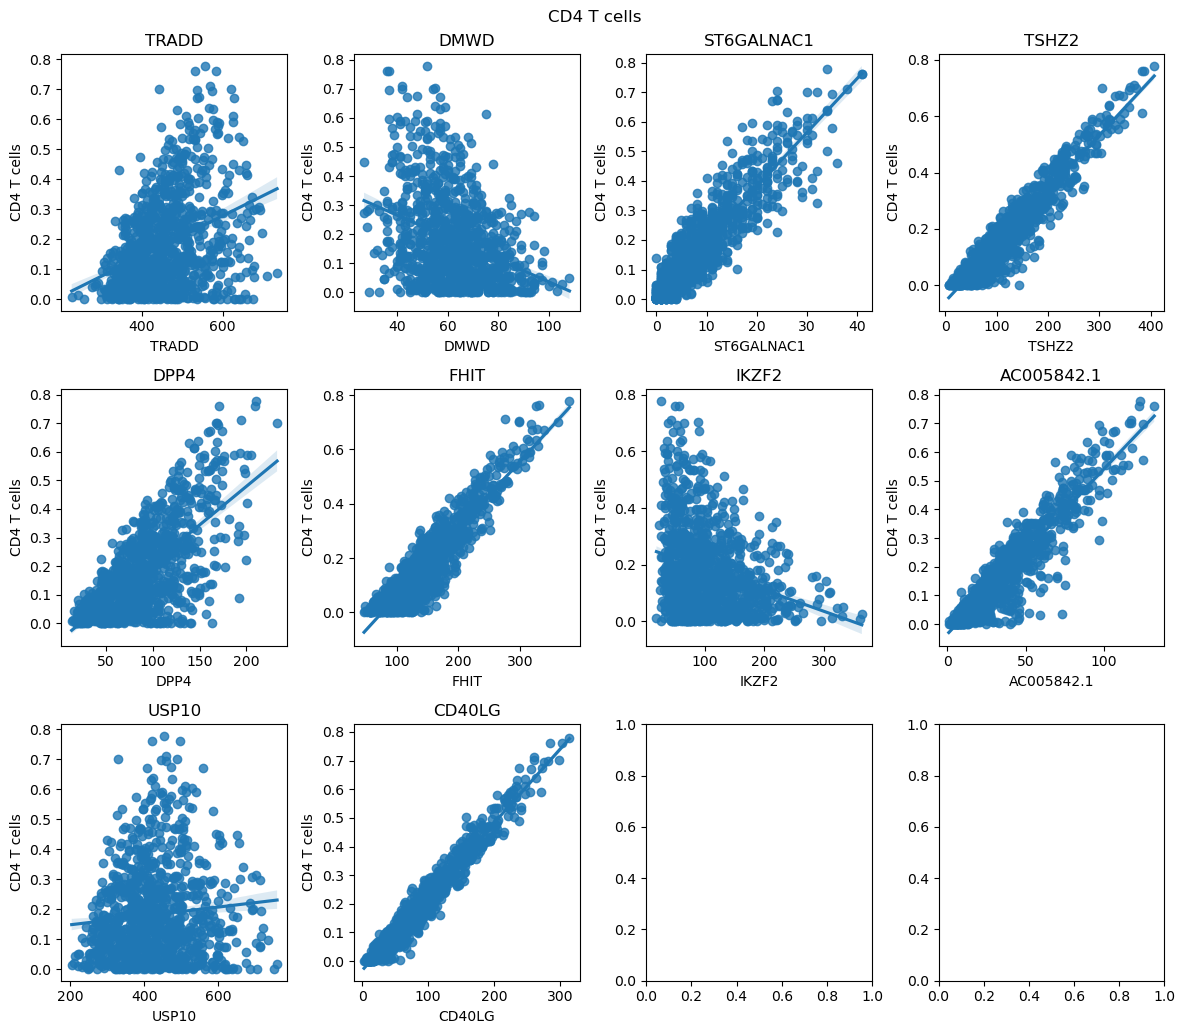

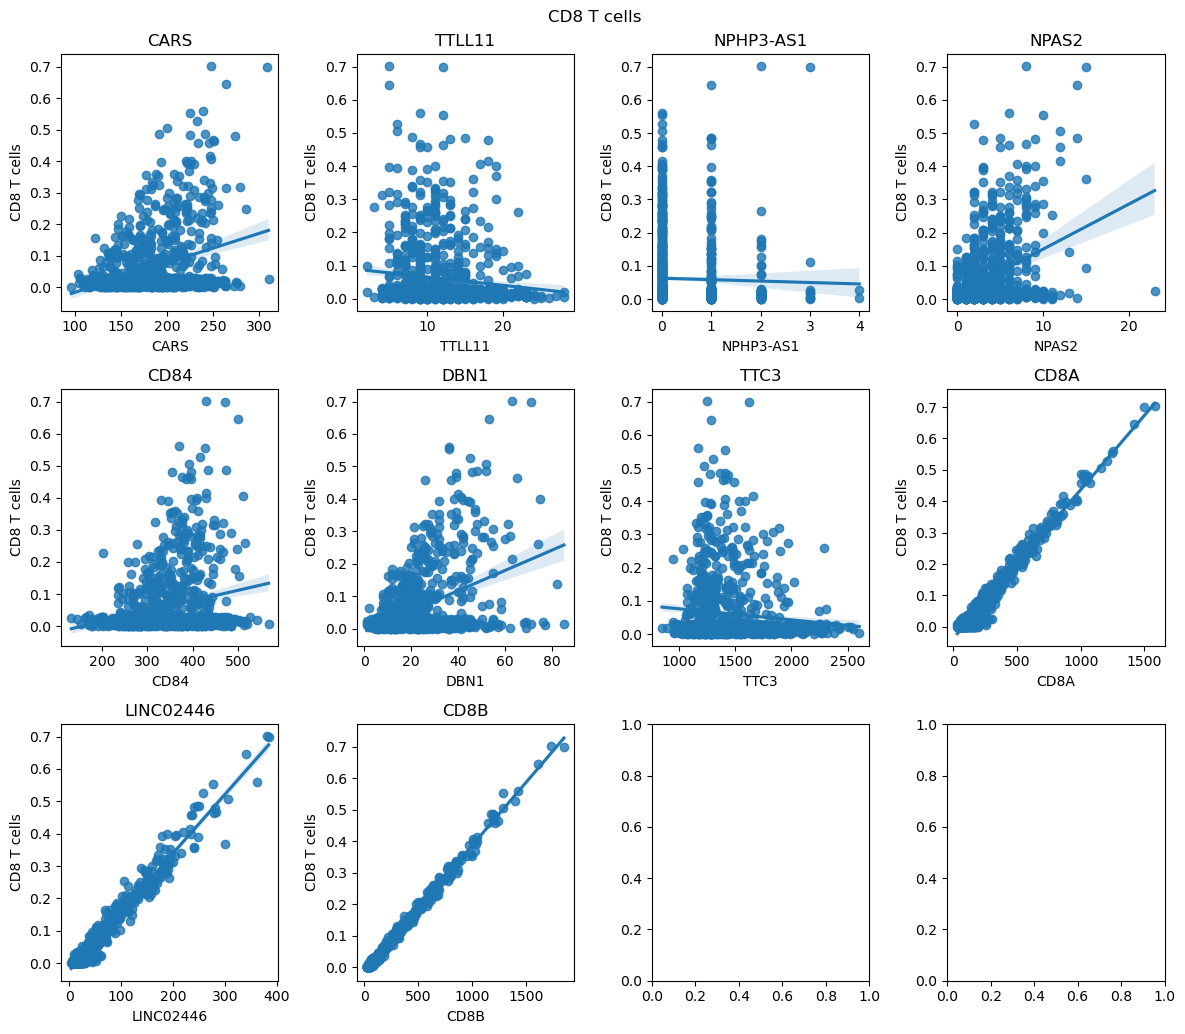

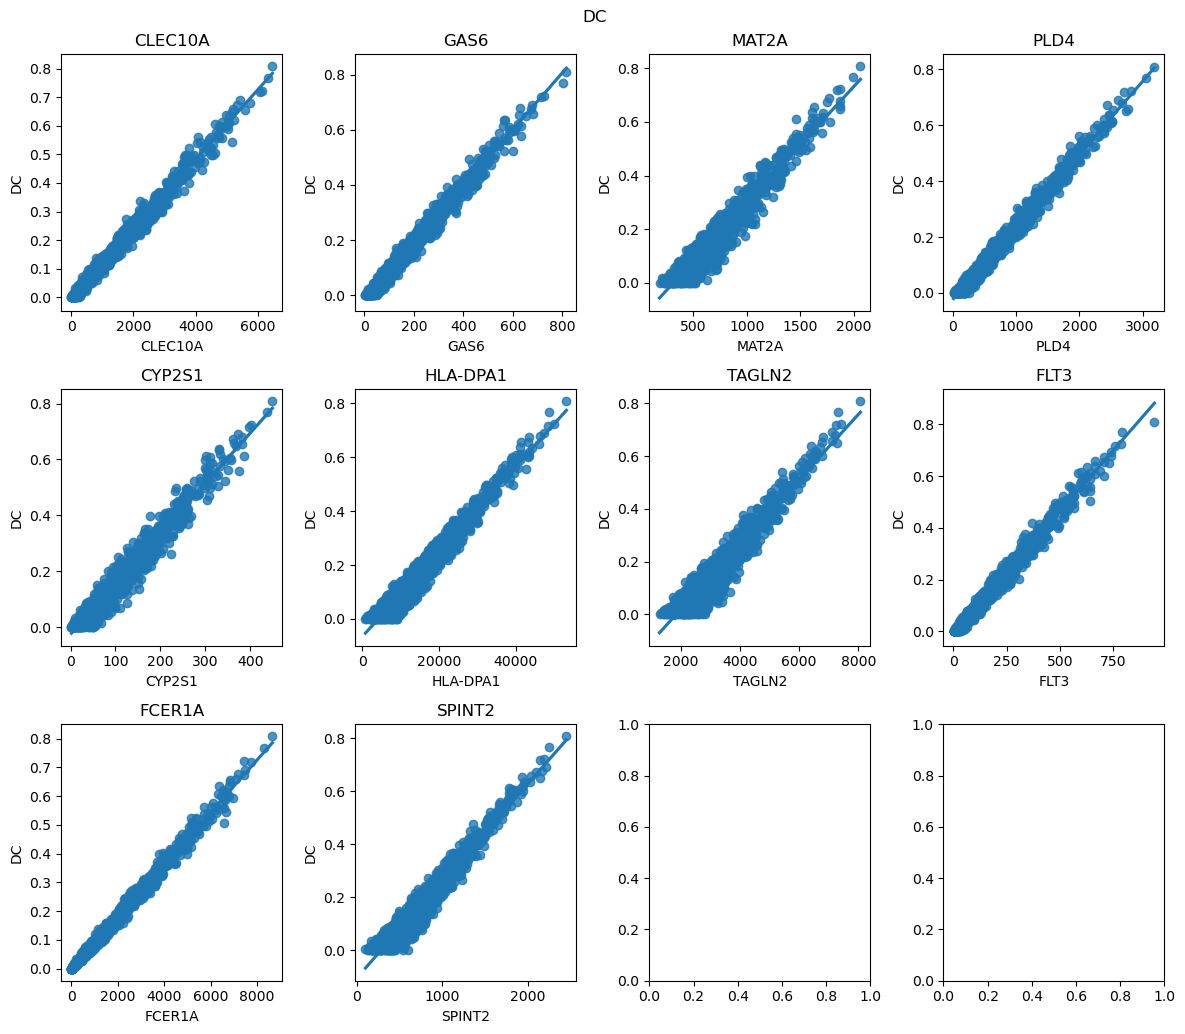

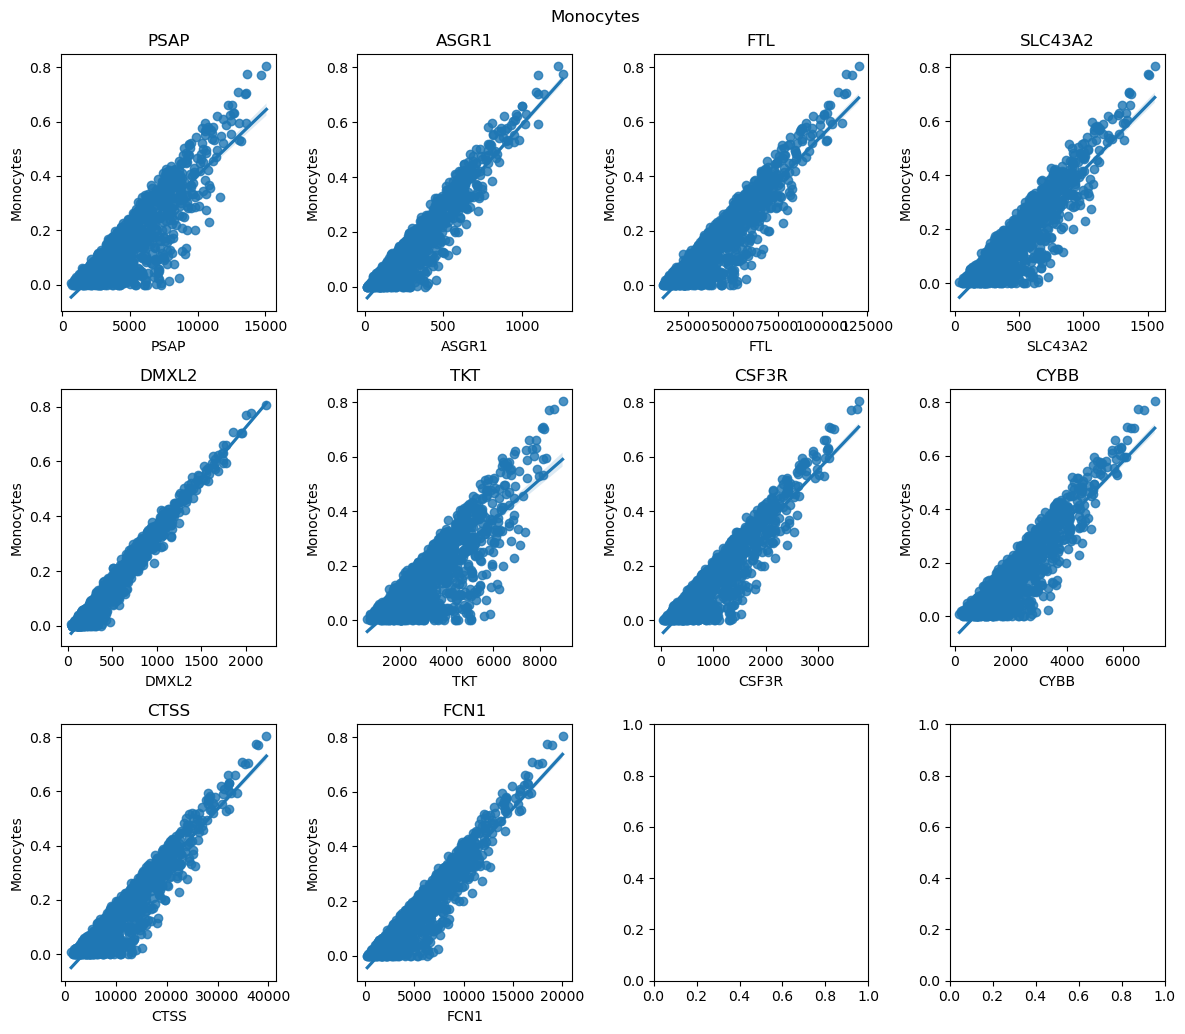

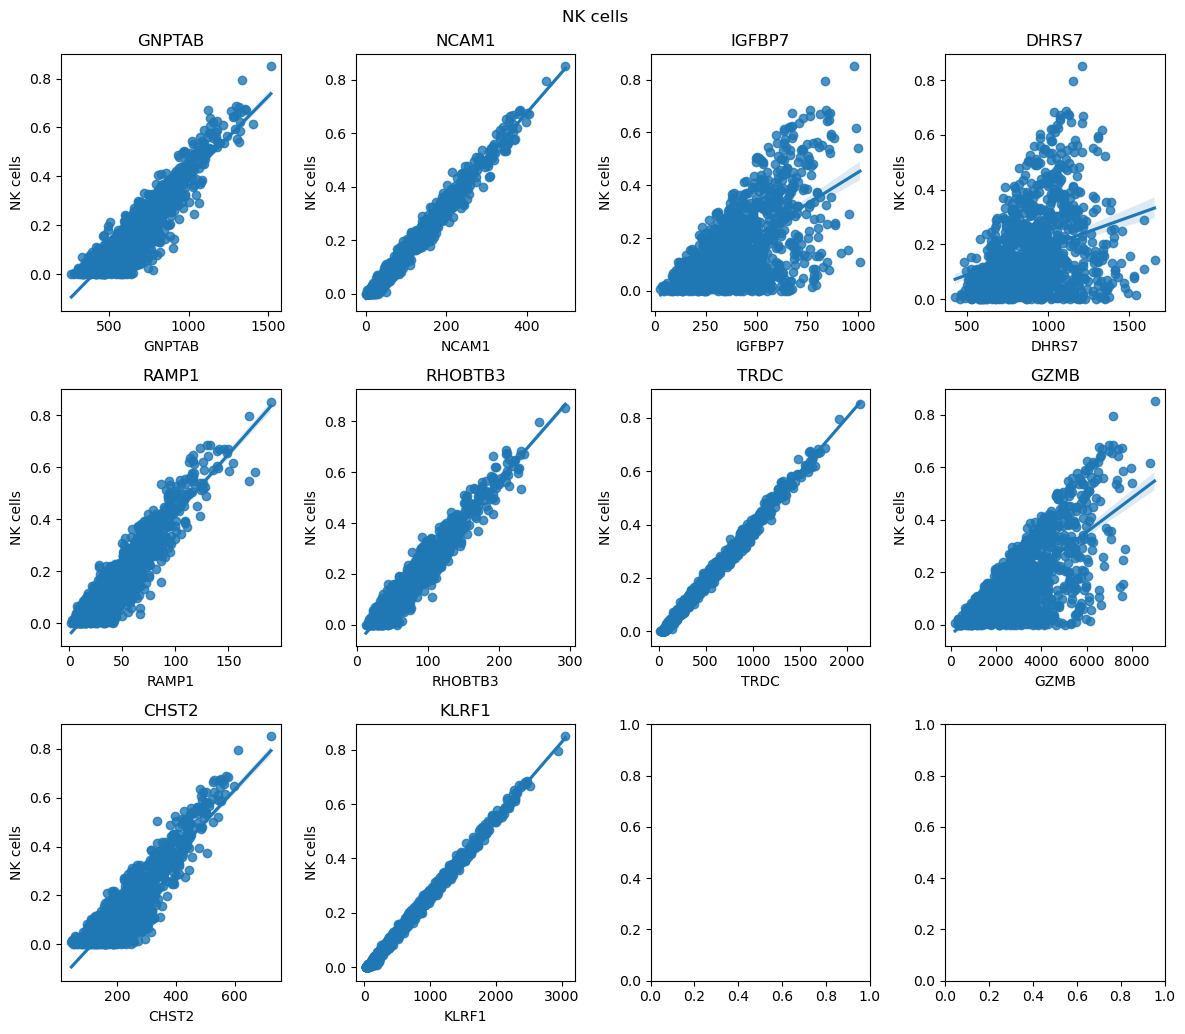

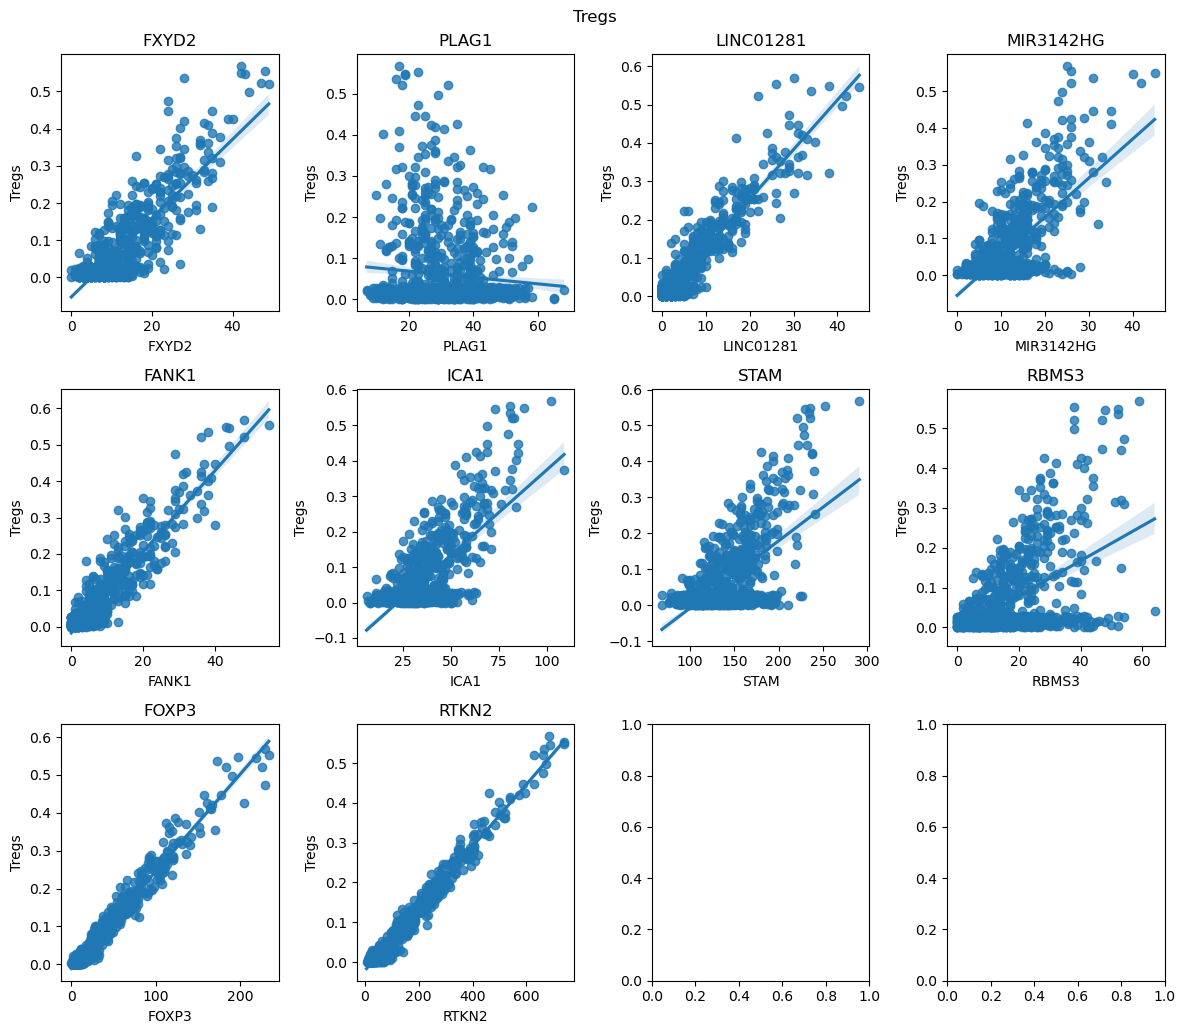

In [42]:
for estimator in estimators:
    plot_marker_prop_expression_correlation(model['model'], estimator, pbs, pb_props, estimators)

In [43]:
bulks = pd.read_csv("../../data/bulk_data/Finotello_2019/final_data/Finotello_TPM_data.csv", index_col=0)
bulk_props = pd.read_csv("../../data/bulk_data/Finotello_2019/final_data/Finotello_FACS_proportions_no_neutrophils_others.csv", index_col=0)

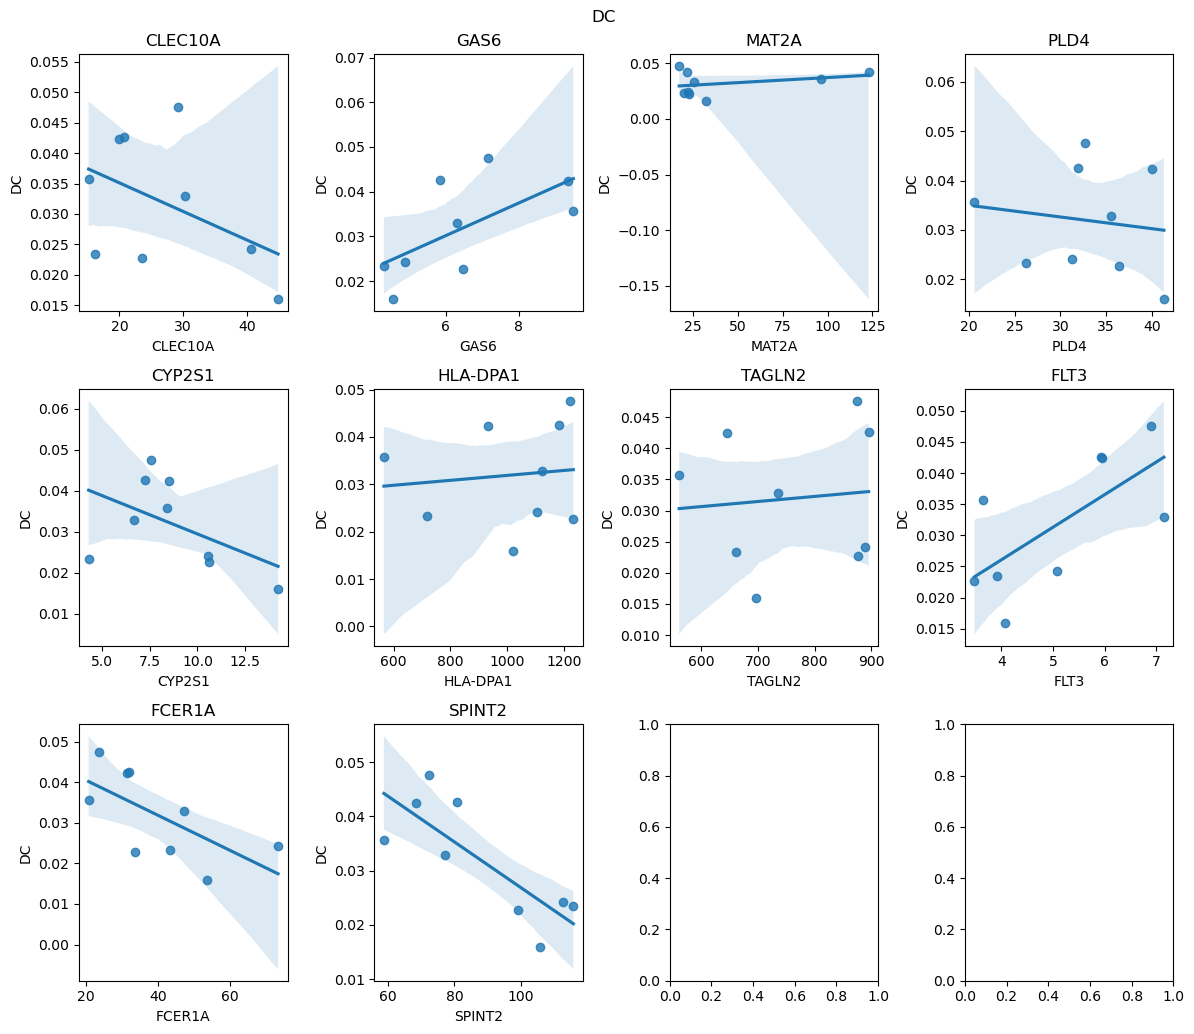

In [46]:
plot_marker_prop_expression_correlation(model['model'], 'DC', bulks, bulk_props, estimators, "DC_bulk_full_spectrum")

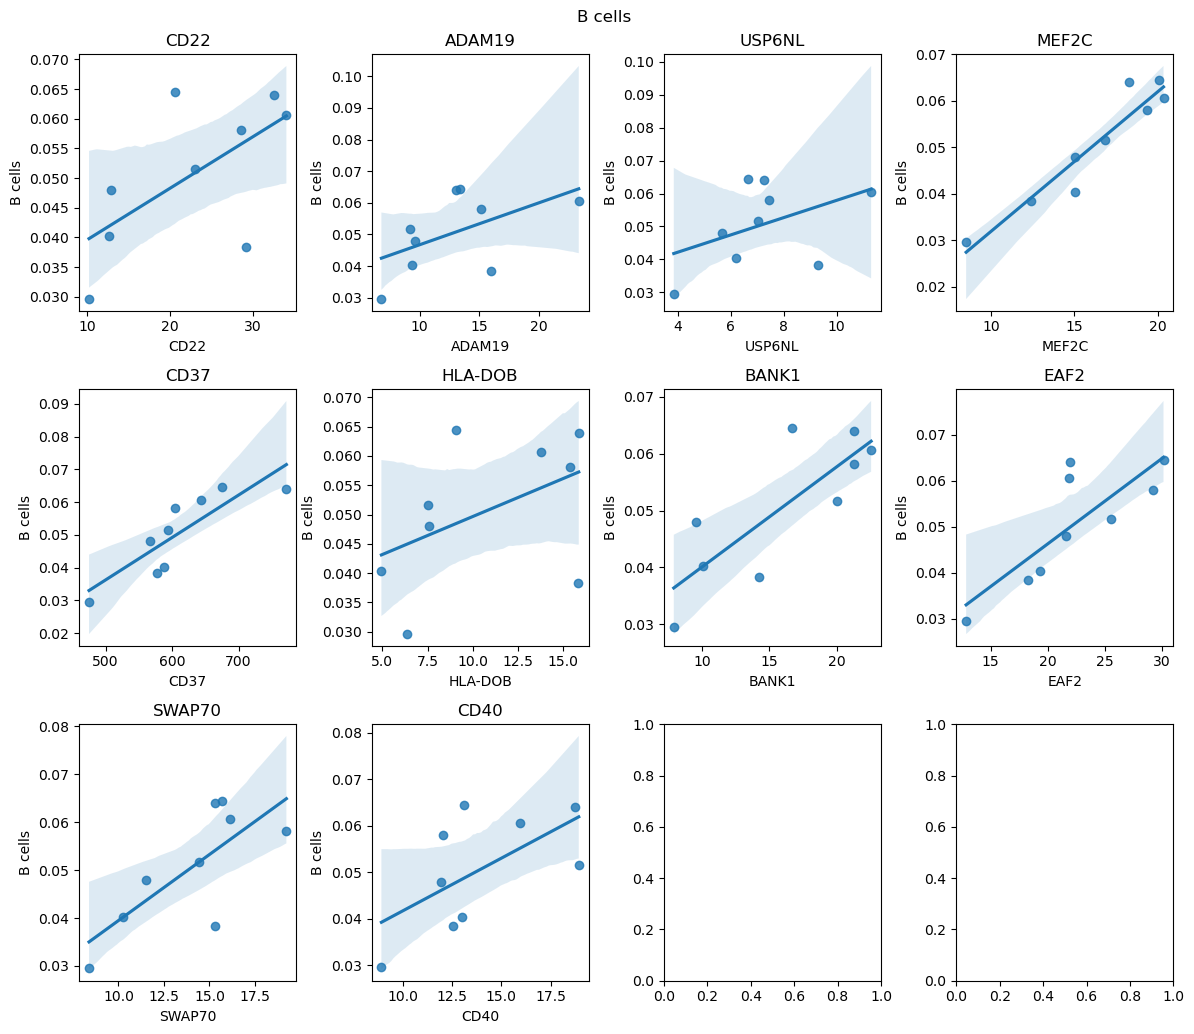

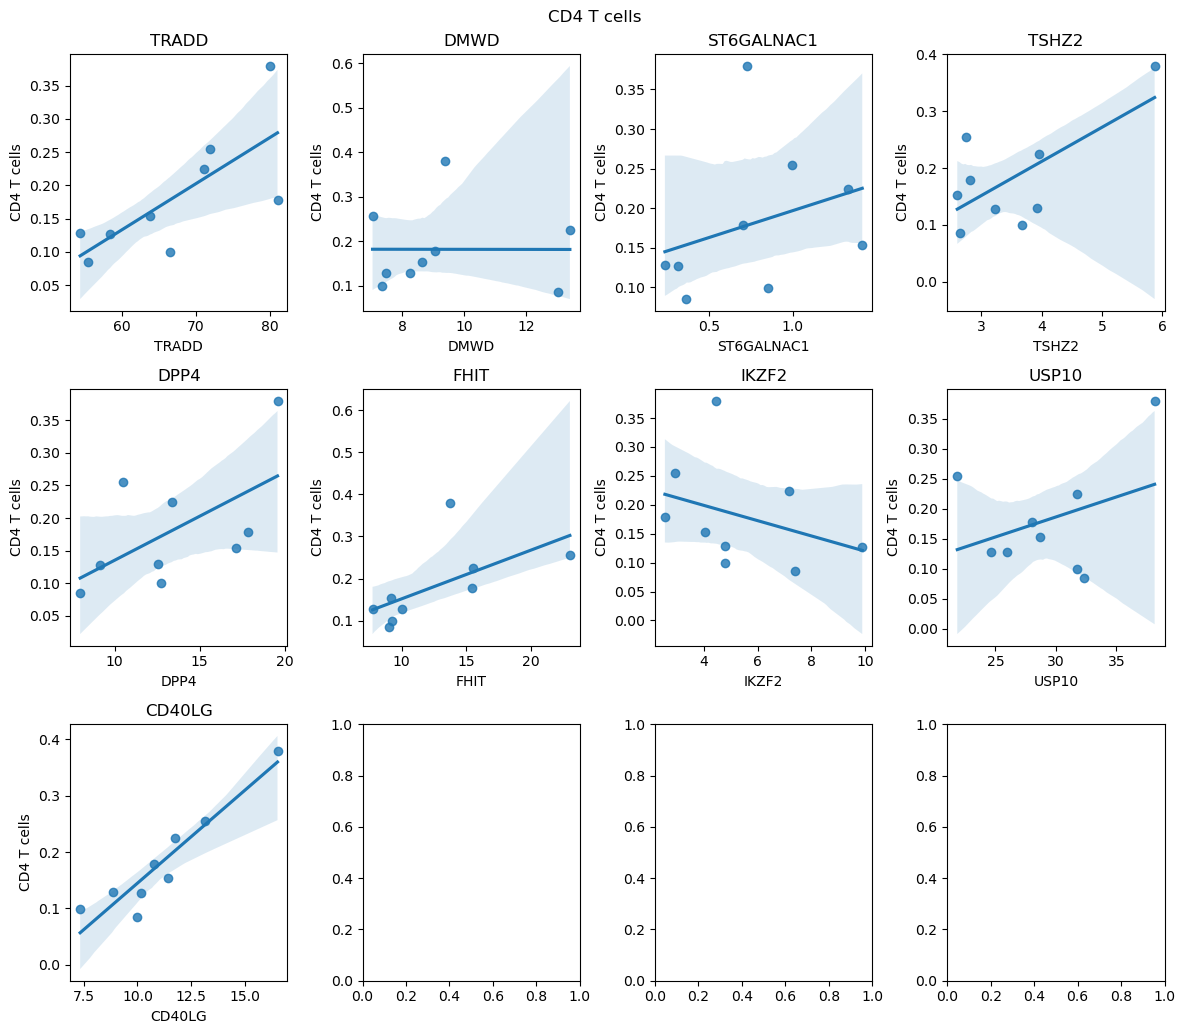

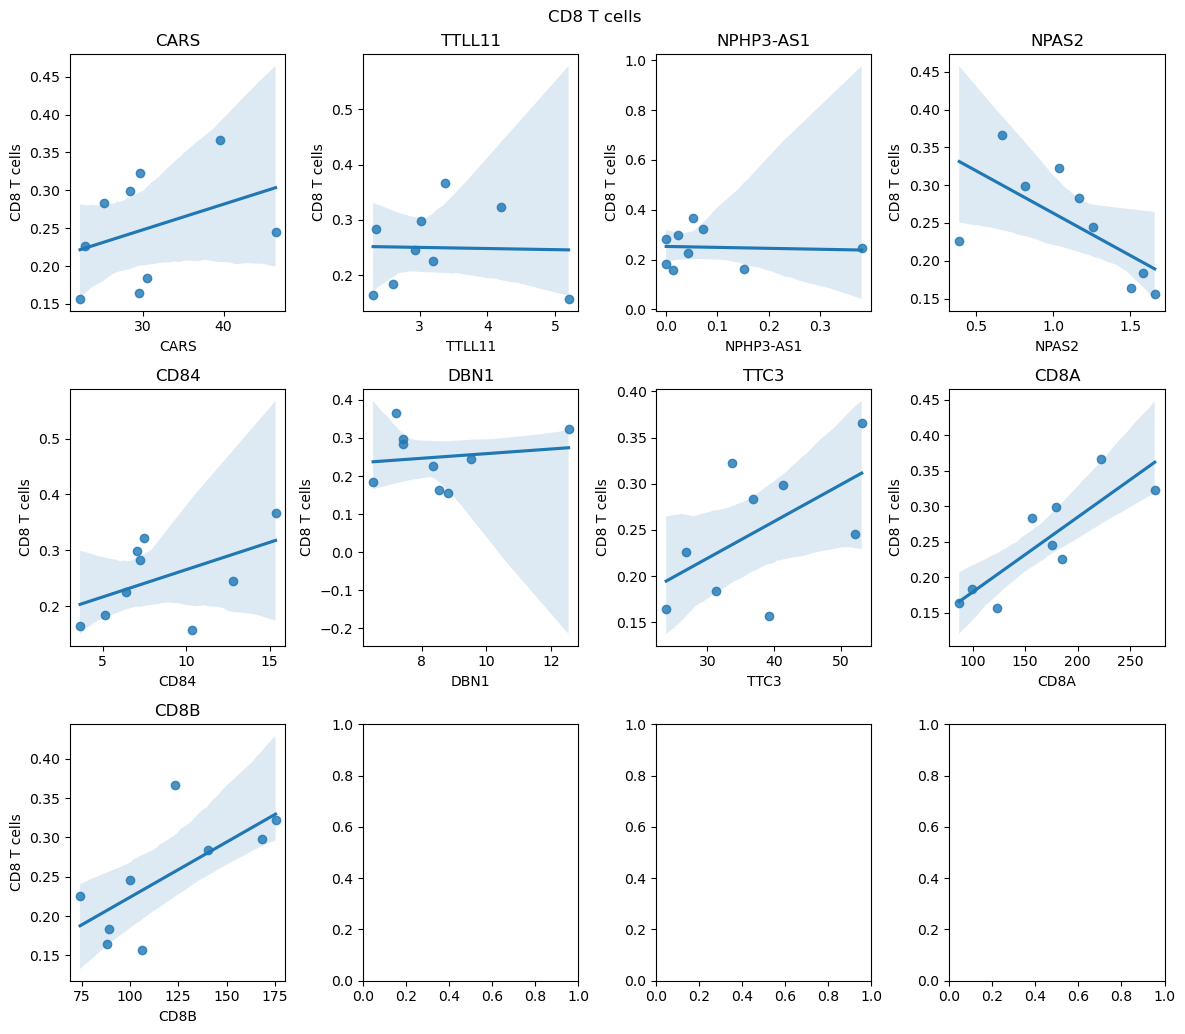

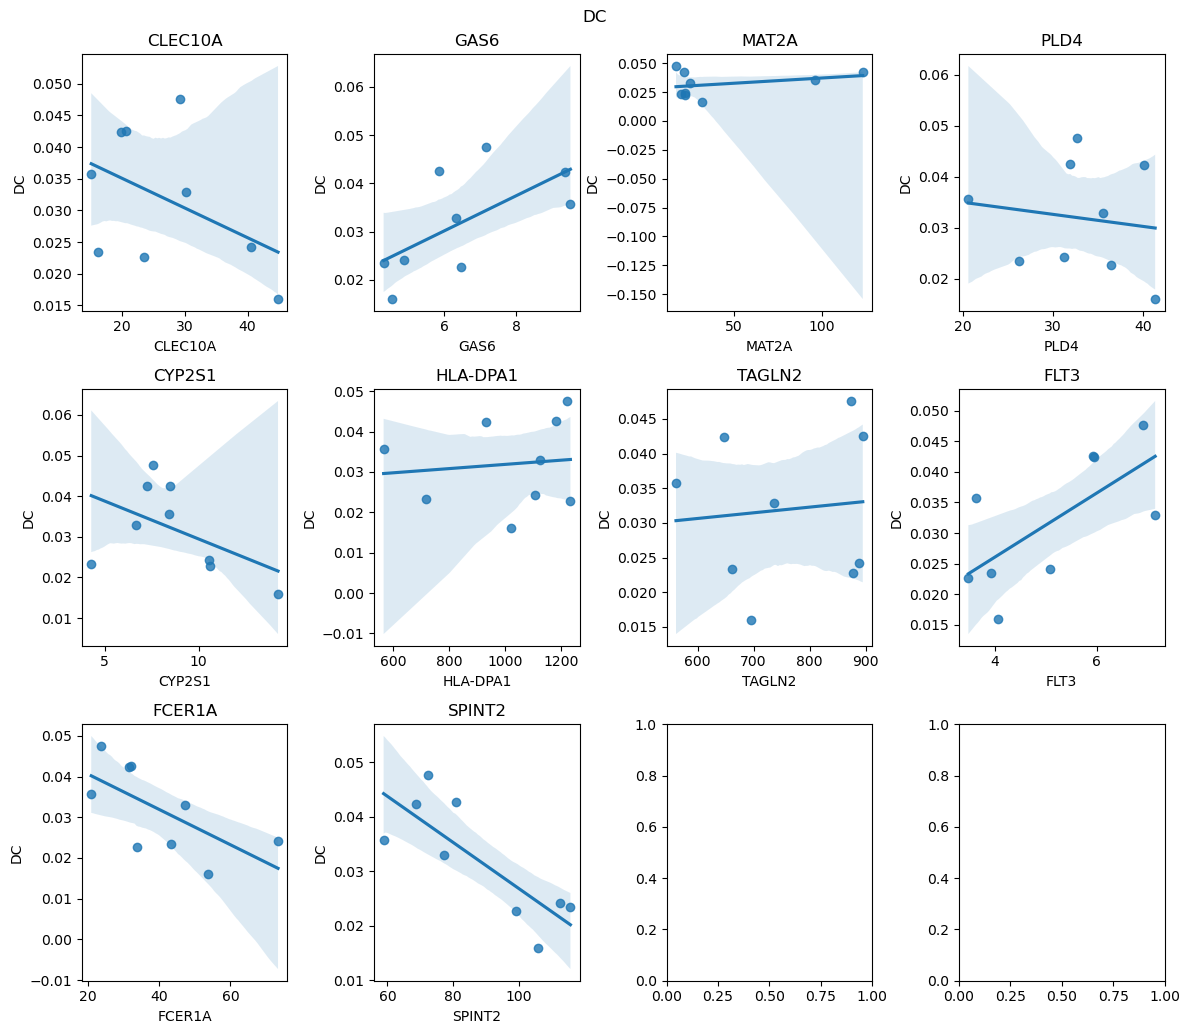

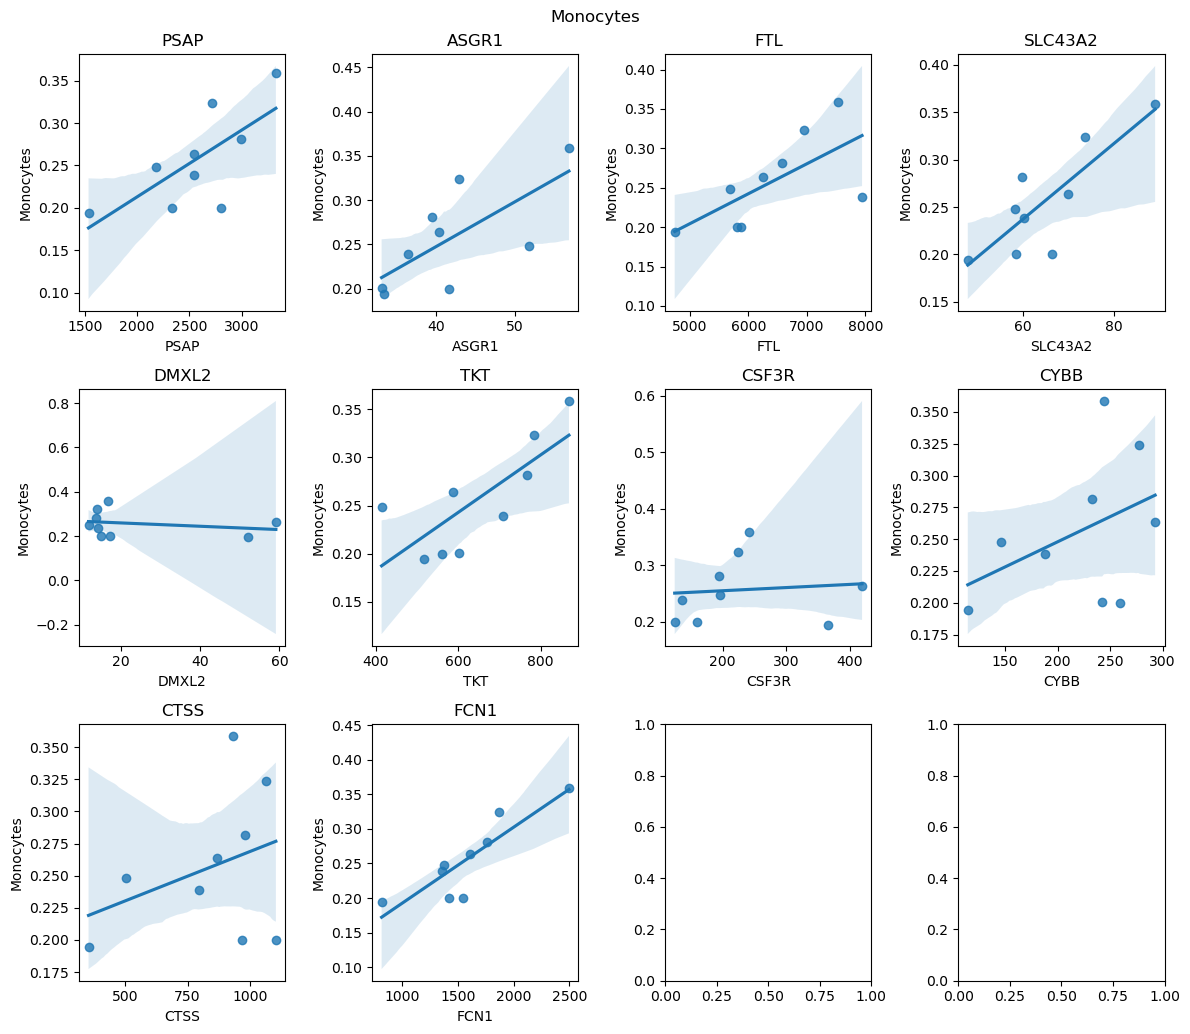

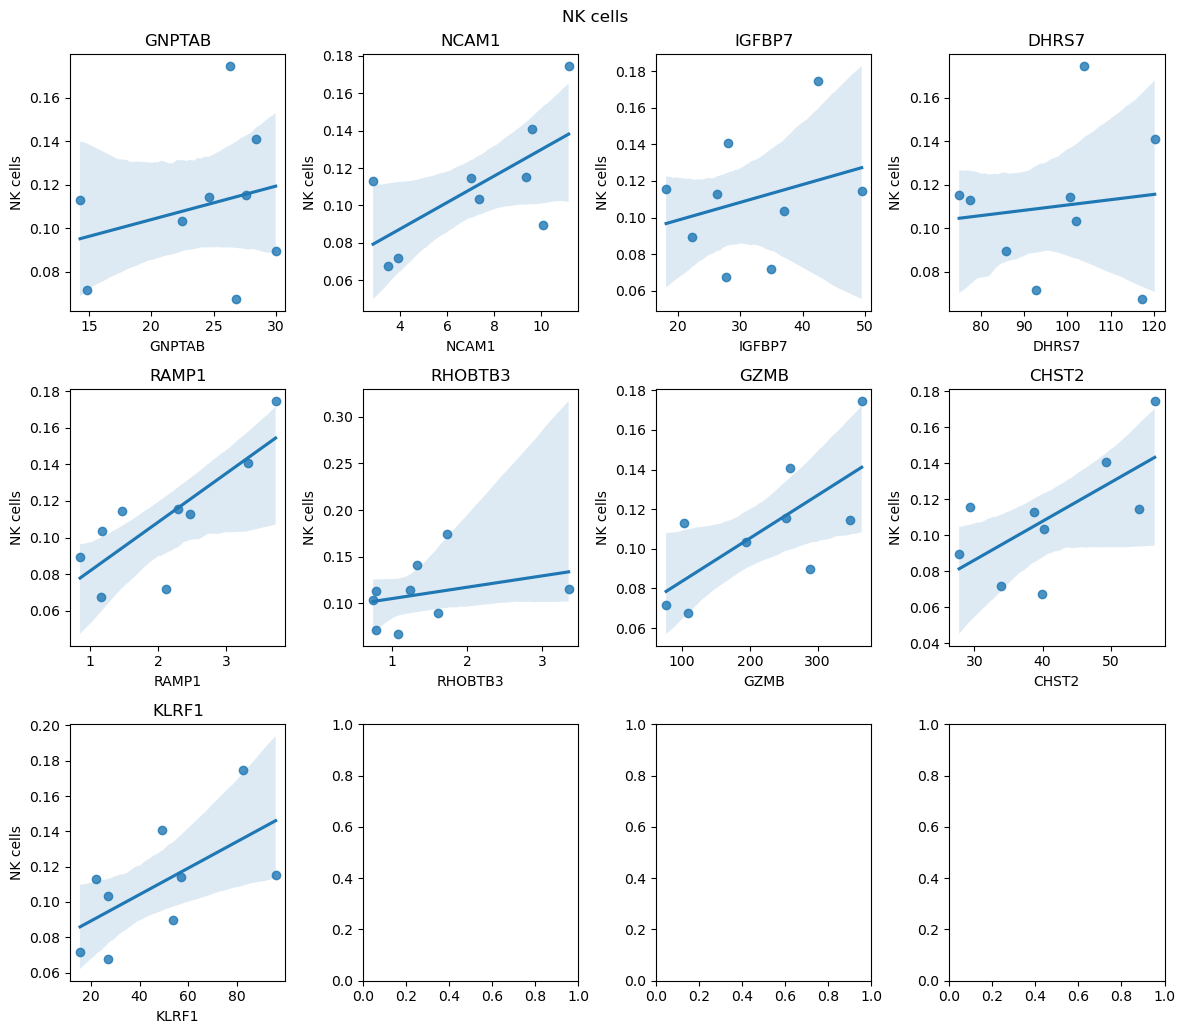

KeyError: "['MIR3142HG'] not in index"

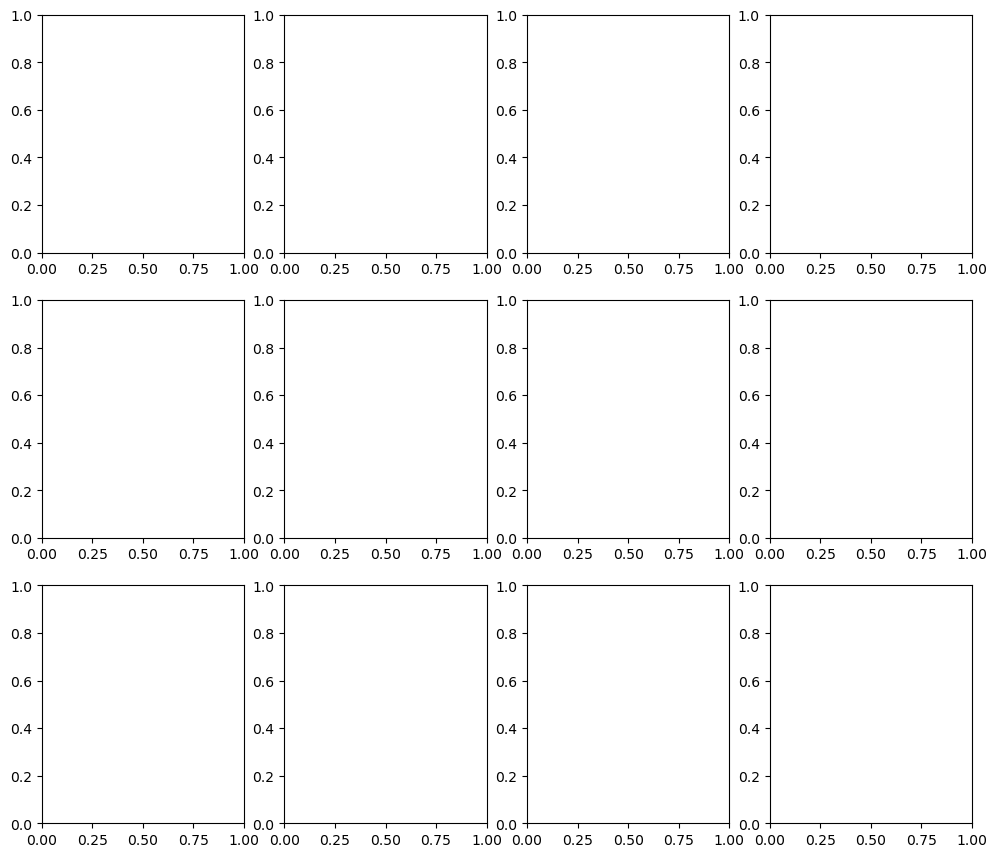

In [49]:
for estimator in estimators:
    plot_marker_prop_expression_correlation(model['model'], estimator, bulks, bulk_props, estimators)

In [50]:
# Subset pb data to low DC proportions

pb_props_subset = pb_props.loc[pb_props['DC']<0.05]
pb_props_subset

,B cells,CD4 T cells,CD8 T cells,DC,Monocytes,NK cells,Tregs
Sample_1,0.000000,0.024048,0.013026,0.031062,0.265531,0.647295,0.019038
Sample_3,0.226908,0.052209,0.023092,0.011044,0.620482,0.055221,0.011044
Sample_9,0.000000,0.144578,0.013052,0.026104,0.214859,0.578313,0.023092
Sample_12,0.277834,0.554664,0.015045,0.000000,0.044132,0.080241,0.028084
Sample_17,0.274824,0.395186,0.028084,0.025075,0.000000,0.258776,0.018054
...,...,...,...,...,...,...,...
Sample_987,0.203815,0.212851,0.116466,0.021084,0.049197,0.051205,0.345382
Sample_988,0.056169,0.125376,0.076229,0.024072,0.304915,0.067202,0.346038
Sample_993,0.187751,0.031124,0.090361,0.033133,0.242972,0.372490,0.042169
Sample_996,0.229920,0.318273,0.125502,0.028112,0.077309,0.062249,0.158635


In [51]:
pbs_subset = pbs.loc[pb_props_subset.index.tolist()]
pbs_subset

,AL627309.1,AL627309.3,AL627309.4,AL669831.5,FAM87B,LINC00115,FAM41C,AL645608.3,SAMD11,NOC2L,...,AC145212.1,MAFIP,AC011043.1,AL592183.1,AC007325.4,AL354822.1,AC004556.1,AC233755.2,AC233755.1,AC240274.1
Sample_1,1.0,0.0,0.0,62.0,0.0,28.0,12.0,0.0,0.0,243.0,...,0.0,9.0,3.0,98.0,8.0,9.0,25.0,0.0,0.0,32.0
Sample_3,0.0,1.0,1.0,74.0,1.0,37.0,18.0,0.0,0.0,301.0,...,1.0,3.0,5.0,163.0,11.0,15.0,32.0,3.0,4.0,61.0
Sample_9,0.0,1.0,0.0,61.0,1.0,14.0,12.0,0.0,0.0,253.0,...,2.0,8.0,3.0,101.0,6.0,9.0,31.0,0.0,0.0,37.0
Sample_12,2.0,0.0,0.0,61.0,2.0,24.0,12.0,3.0,1.0,211.0,...,0.0,6.0,3.0,141.0,7.0,11.0,16.0,1.0,0.0,35.0
Sample_17,1.0,0.0,0.0,52.0,0.0,23.0,15.0,1.0,0.0,244.0,...,0.0,3.0,2.0,129.0,1.0,10.0,12.0,0.0,7.0,26.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Sample_987,1.0,0.0,0.0,47.0,0.0,15.0,9.0,0.0,0.0,200.0,...,2.0,6.0,3.0,114.0,4.0,10.0,15.0,0.0,7.0,33.0
Sample_988,2.0,0.0,2.0,52.0,0.0,28.0,19.0,0.0,0.0,231.0,...,1.0,4.0,4.0,94.0,7.0,8.0,16.0,0.0,2.0,43.0
Sample_993,3.0,0.0,0.0,61.0,0.0,18.0,16.0,0.0,1.0,264.0,...,3.0,10.0,5.0,135.0,9.0,12.0,21.0,5.0,0.0,41.0
Sample_996,0.0,0.0,0.0,49.0,0.0,18.0,10.0,0.0,0.0,202.0,...,2.0,4.0,2.0,122.0,4.0,7.0,17.0,0.0,2.0,32.0


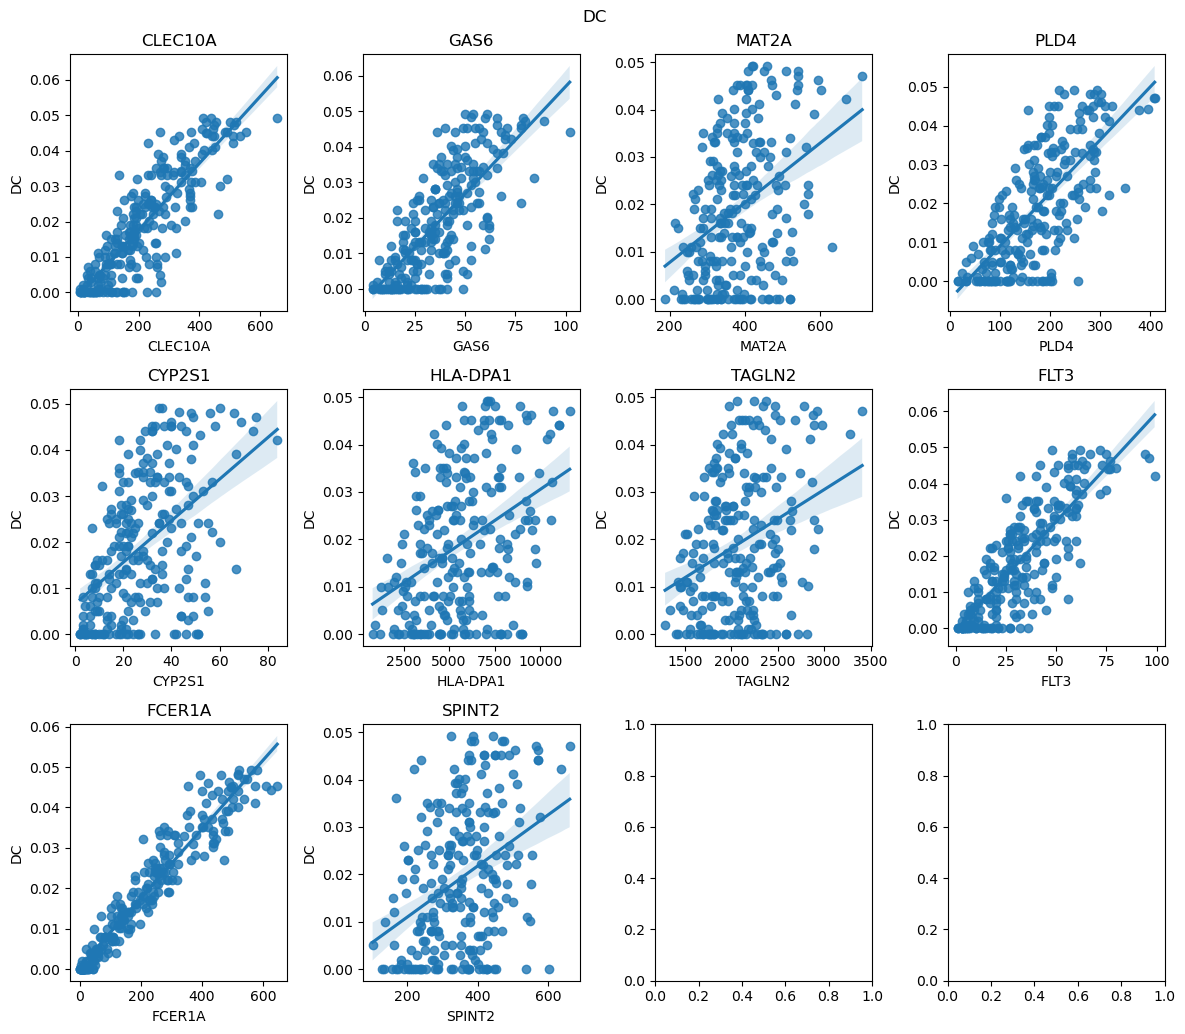

In [52]:
plot_marker_prop_expression_correlation(model['model'], 'DC', pbs_subset, pb_props_subset, estimators, "DC_pb_bulk_spectrum")

### Investigate Marker gene overlap

In [35]:
marker_db = pd.read_excel('Cell_marker_2.0_all_human_markers.xlsx')
marker_db

,species,tissue_class,tissue_type,uberonongology_id,cancer_type,cell_type,cell_name,cellontology_id,marker,Symbol,GeneID,Genetype,Genename,UNIPROTID,technology_seq,marker_source,PMID,Title,journal,year
0,Human,Abdomen,Abdomen,UBERON_0000916,Normal,Normal cell,Macrophage,CL_0000235,MERTK,MERTK,10461.0,protein_coding,"MER proto-oncogene, tyrosine kinase",Q12866,NaN,Experiment,31982413.0,Peritoneal Level of CD206 Associates With Mort...,Gastroenterology,2020.0
1,Human,Abdomen,Abdomen,UBERON_0000916,Normal,Normal cell,Macrophage,CL_0000235,CD16,FCGR3A,2215.0,protein_coding,Fc fragment of IgG receptor IIIb,O75015,NaN,Experiment,31982413.0,Peritoneal Level of CD206 Associates With Mort...,Gastroenterology,2020.0
2,Human,Abdomen,Abdomen,UBERON_0000916,Normal,Normal cell,Macrophage,CL_0000235,CD206,MRC1,4360.0,protein_coding,mannose receptor C-type 1,P22897,NaN,Experiment,31982413.0,Peritoneal Level of CD206 Associates With Mort...,Gastroenterology,2020.0
3,Human,Abdomen,Abdomen,UBERON_0000916,Normal,Normal cell,Macrophage,CL_0000235,CRIg,VSIG4,11326.0,protein_coding,V-set and immunoglobulin domain containing 4,Q9Y279,NaN,Experiment,31982413.0,Peritoneal Level of CD206 Associates With Mort...,Gastroenterology,2020.0
4,Human,Abdomen,Abdomen,UBERON_0000916,Normal,Normal cell,Macrophage,CL_0000235,CD163,CD163,9332.0,protein_coding,CD163 molecule,Q86VB7,NaN,Experiment,31982413.0,Peritoneal Level of CD206 Associates With Mort...,Gastroenterology,2020.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60872,Human,Vein,Vein,UBERON_0001638,Normal,Normal cell,Venous cell,NaN,LRG1,LRG1,116844.0,protein_coding,leucine rich alpha-2-glycoprotein 1,P02750,10x Chromium,Experiment,33996252.0,Single-cell transcriptomics reveals the landsc...,Molecular therapy. Nucleic acids,2021.0
60873,Human,Vein,Vein,UBERON_0001638,Normal,Normal cell,Venous cell,NaN,EMCN,EMCN,51705.0,protein_coding,endomucin,Q9ULC0,10x Chromium,Experiment,33996252.0,Single-cell transcriptomics reveals the landsc...,Molecular therapy. Nucleic acids,2021.0
60874,Human,Vein,Vein,UBERON_0001638,Normal,Normal cell,Systemic–venous endothelial cell,NaN,COL15A1,COL15A1,1306.0,protein_coding,collagen type XV alpha 1 chain,B3KTP7,10x Chromium,Experiment,34030460.0,Integrated Single-Cell Atlas of Endothelial Ce...,Circulation,2021.0
60875,Human,NaN,Intestine,UBERON_0000160,Normal,Normal cell,B cell,CL_0000236,CD19,CD19,930.0,protein_coding,CD19 molecule,P15391,10x Chromium,Experiment,34269788.0,CD16+CD163+ monocytes traffic to sites of infl...,The Journal of experimental medicine,2021.0


In [36]:
search_dict = {
    "B cells": ["B cell", "B cells"],
    "CD4 T cells" : ["CD4+ T cell", "CD4 T cell"],
    "CD8 T cells" : ["CD8+ T cell", "CD8 T cell"],
    "DC" : ["Dendritic cell", "dendritic cell"],
    "Monocytes" : ["monocyte"],
    "NK cells" : ["NK cell", "Natural killer"],
    "Tregs" : ["Treg"]
}

def marker_feature_overlap(model, marker_db, search_dict, n_markers):

    import re

    return_dict = {}

    for estimator in search_dict.keys():
        # Get list of genes and the index of the celltype currently handled from the model
        genes = model['model'].estimators_[0].feature_names_in_.tolist()
        index = model['metadata']['estimators'].index(estimator)

        # Get the 10 most informative genes
        feature_importance = model['model'].estimators_[index].feature_importances_
        sorted_idx = np.argsort(feature_importance) # sort highest to lowest importance and get the feature indices
        most_important_features = sorted_idx[-n_markers:] # get 20 most important features
        grood_marker_genes = list(np.array(genes)[most_important_features])

        # For the celltype extract the markers from the db
        search_terms = search_dict[estimator]
        pattern = "|".join(re.escape(term) for term in search_terms)

        cell_marker_subset = marker_db[marker_db["cell_name"].str.contains(pattern, case=False, na=False)]
        cell_marker_genes = cell_marker_subset["Symbol"].dropna().drop_duplicates().tolist()

        # Overlap between grood markers and cell markers
        overlap = len(list(set(set(grood_marker_genes) - set(set(grood_marker_genes)-set(cell_marker_genes))))) / len(list(set(grood_marker_genes)))
        print(overlap)

        return_dict[estimator] = {'grood_markers': grood_marker_genes, 'cell_markers' : cell_marker_genes, 'overlap' : overlap}

    return return_dict

for y in [5,10,15,20]:
    print(f"------ n_markers: {y} ------")
    _ = marker_feature_overlap(model, marker_db, search_dict, y)

------ n_markers: 5 ------
1.0
0.6
0.4
0.6
1.0
0.8
0.8
------ n_markers: 10 ------
0.9
0.5
0.3
0.6
1.0
0.7
0.5
------ n_markers: 15 ------
0.9333333333333333
0.4
0.26666666666666666
0.4666666666666667
1.0
0.6666666666666666
0.4
------ n_markers: 20 ------
0.9
0.45
0.2
0.5
1.0
0.7
0.3


In [37]:
marker_overlap = marker_feature_overlap(model, marker_db, search_dict, 10)
marker_overlap

0.9
0.5
0.3
0.6
1.0
0.7
0.5


{'B cells': {'grood_markers': ['CD22',
   'ADAM19',
   'USP6NL',
   'MEF2C',
   'CD37',
   'HLA-DOB',
   'BANK1',
   'EAF2',
   'SWAP70',
   'CD40'],
  'cell_markers': ['IGKC',
   'IGHG3',
   'GABRP',
   'MS4A1',
   'CD19',
   'SCGB1A1',
   'KRT78',
   'MUC5B',
   'EPCAM',
   'FCRL5',
   'CD38',
   'CD86',
   'CD79A',
   'CD27',
   'SPIB',
   'CD7',
   'CD3D',
   'MZB1',
   'CD5',
   'TAGLN2',
   'CD69',
   'ITGAX',
   'CD72',
   'LILRB2',
   'ZAP70',
   'PTPRC',
   'CD24',
   'CR2',
   'CD74',
   'CD79B',
   'BLNK',
   'CD37',
   'SPN',
   'DLX4',
   'FAS',
   'TBX21',
   'LILRA4',
   'JCHAIN',
   'IGHG2',
   'IGHG1',
   'CD22',
   'ZCCHC7',
   'HLA-A',
   'MME',
   'CALR',
   'TNFRSF17',
   'XBP1',
   'BACH2',
   'CD40',
   'CD70',
   'CD80',
   'IL7R',
   'IL2RA',
   'CD81',
   'FCGR2A',
   'IGHM',
   'PAX5',
   'ITGB1',
   'FCRLA',
   'IGHA1',
   'IGHD',
   'FCER2',
   'TCL1A',
   'BCL11A',
   'PLPP5',
   'TNFSF13B',
   'AICDA',
   'TFRC',
   'CD28',
   'FCRL1',
   'TNFRSF13C',
   

In [38]:
for ct in marker_overlap.keys():
    print(f"Celltype: {ct} | Marker overlap: {marker_overlap[ct]['overlap']}")

Celltype: B cells | Marker overlap: 0.9
Celltype: CD4 T cells | Marker overlap: 0.5
Celltype: CD8 T cells | Marker overlap: 0.3
Celltype: DC | Marker overlap: 0.6
Celltype: Monocytes | Marker overlap: 1.0
Celltype: NK cells | Marker overlap: 0.7
Celltype: Tregs | Marker overlap: 0.5


In [39]:
import math
import re

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch


def plot_marker_feature_overlap(
    model,
    marker_db,
    search_dict,
    n_markers=20,
):
    """
    Plot the most important features for each GrooD/XGrooD estimator.

    Bars are green when the gene is annotated for the corresponding cell type
    in marker_db and gray otherwise.

    Parameters
    ----------
    model : dict
        Dictionary containing:
        - model["model"]: fitted GrooD/XGrooD model
        - model["metadata"]["estimators"]: estimator/cell-type names

    marker_db : pandas.DataFrame
        Marker database containing at least the columns:
        "cell_name" and "Symbol".

    search_dict : dict
        Maps estimator names to search terms used for matching cell_name.

    n_markers : int, default=20
        Number of top features to display per estimator.

    Returns
    -------
    dict
        Marker genes, model-derived marker genes, overlapping genes,
        and overlap fraction for each estimator.
    """

    fitted_model = model["model"]
    estimators = model["metadata"]["estimators"]
    genes = np.asarray(
        fitted_model.estimators_[0].feature_names_in_,
        dtype=str,
    )

    # Normalize database symbols once for case-insensitive comparison
    marker_db = marker_db.copy()
    marker_db["Symbol_normalized"] = (
        marker_db["Symbol"]
        .astype("string")
        .str.strip()
        .str.upper()
    )

    # Configure subplots
    n = len(estimators)
    rows = math.floor(math.sqrt(n))
    cols = math.ceil(n/rows)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 4))
    axes = np.array(axes) # axes must be an iterable array

    axes = axes.flatten() # flatten in case of multi-dimensionality

    return_dict = {}

    for i, estimator in enumerate(estimators):

        if estimator not in search_dict:
            raise KeyError(
                f"No search terms were defined for estimator {estimator!r}."
            )

        # Extract marker annotations for the current cell type
        search_terms = search_dict[estimator]
        pattern = "|".join(re.escape(term) for term in search_terms)

        cell_marker_subset = marker_db[
            marker_db["cell_name"].str.contains(
                pattern,
                case=False,
                na=False,
                regex=True,
            )
        ]

        cell_marker_genes = (
            cell_marker_subset["Symbol"]
            .dropna()
            .astype(str)
            .str.strip()
            .drop_duplicates()
            .tolist()
        )

        # Use normalized symbols for robust comparison
        cell_marker_gene_set = set(
            cell_marker_subset["Symbol_normalized"].dropna()
        )

        # Extract the most important model features
        feature_importance = fitted_model.estimators_[i].feature_importances_

        n_current = min(n_markers, len(feature_importance))
        most_important_indices = np.argsort(feature_importance)[-n_current:]

        grood_marker_genes = genes[most_important_indices]
        grood_marker_normalized = np.char.upper(
            np.char.strip(grood_marker_genes)
        )

        is_annotated = np.array([
            gene in cell_marker_gene_set
            for gene in grood_marker_normalized
        ])

        overlapping_genes = grood_marker_genes[is_annotated].tolist()
        overlap = is_annotated.mean() if len(is_annotated) else np.nan

        # Assign one color per displayed gene
        bar_colors = np.where(
            is_annotated,
            "mediumseagreen",
            "lightgray",
        )

        positions = np.arange(n_current)

        axes[i].barh(
            positions,
            feature_importance[most_important_indices],
            color=bar_colors,
            align="center",
        )

        axes[i].set_yticks(
            positions,
            labels=grood_marker_genes,
        )
        axes[i].set_title(
            f"{estimator}\nMarker overlap: {overlap:.0%}"
        )
        axes[i].set_xlabel("Feature importance")

        return_dict[estimator] = {
            "grood_markers": grood_marker_genes.tolist(),
            "cell_markers": cell_marker_genes,
            "overlapping_markers": overlapping_genes,
            "overlap": overlap,
        }

    legend_ax = axes[-1]
    legend_ax.axis("off")

    legend_ax.legend(
        handles=[
            Patch(facecolor="mediumseagreen", label="Covered by marker database"),
            Patch(facecolor="lightgray", label="Not covered by marker database"),
        ],
        loc="center",
        frameon=False,
    )

    plt.tight_layout()
    plt.savefig(f'SI_Figure_1F.svg', transparent = True, dpi = 300, format = 'svg')
    plt.show()

    return return_dict

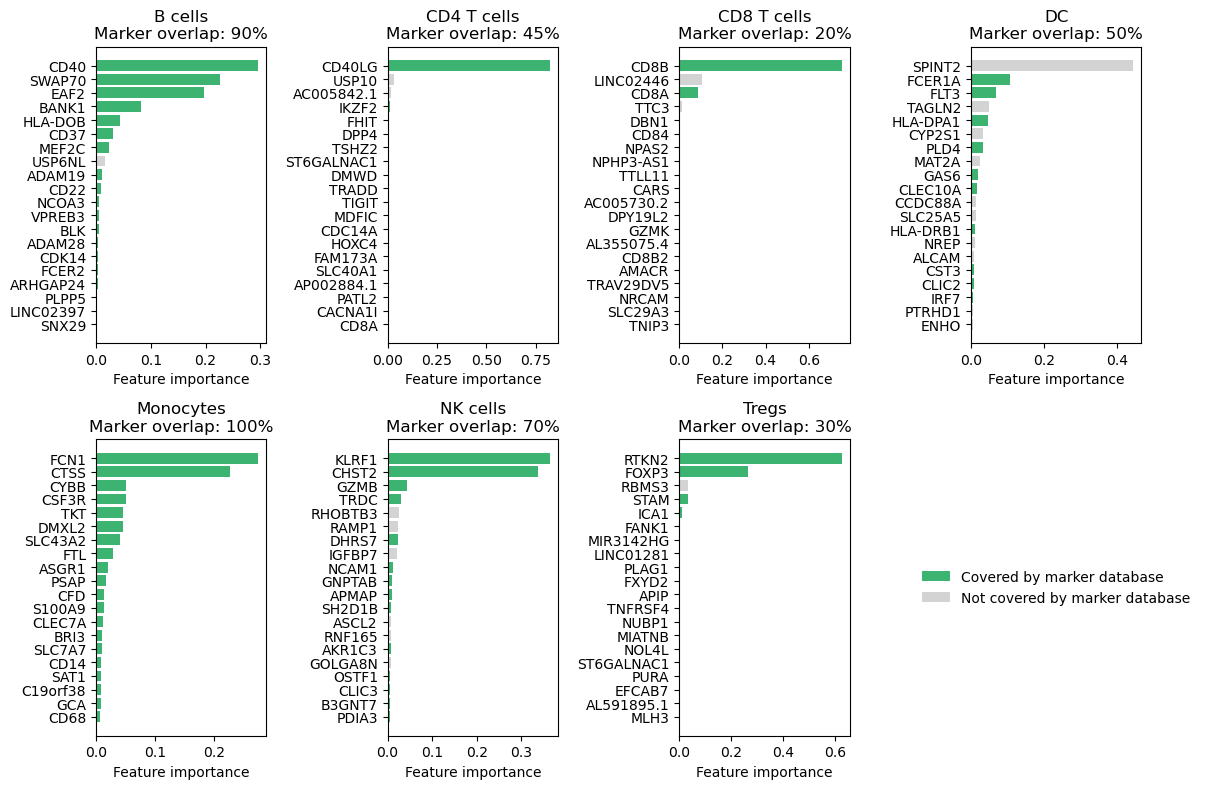

In [40]:
marker_overlap = plot_marker_feature_overlap(
    model=model,
    marker_db=marker_db,
    search_dict=search_dict,
    n_markers=20,
)